In [ ]:
import numpy as np
import os
import glob
from scipy.io import loadmat
from skimage.measure import regionprops, find_contours
from skimage.morphology import binary_erosion
from skimage import io
import pandas as pd
from itertools import permutations

class TumorFeatureExtractor:
    def __init__(self):
        self.dim = 1  # embedding dimension
        self.r = 0.2  # tolerance for entropy calculations
        self.uniform_intervals = 128
        self.Kmax = 4  # maximum number of sub-series for Higuchi fractal

    def diagnose_masks(self, dataset_folder, num_samples=5):
        """
        Diagnose mask files to understand their format and content

        Args:
            dataset_folder: path to Brain_Dataset folder
            num_samples: number of samples to check per class
        """
        print("=== MASK DIAGNOSIS ===")
        class_names = ['glioma', 'meningioma', 'pituitary']

        for class_name in class_names:
            class_folder = os.path.join(dataset_folder, class_name)
            if not os.path.exists(class_folder):
                continue

            print(f"\n📁 Checking {class_name} masks...")
            image_files = glob.glob(os.path.join(class_folder, "*_image.png"))[:num_samples]

            for image_path in image_files:
                base_name = os.path.basename(image_path).replace('_image.png', '')
                mask_path = os.path.join(class_folder, f"{base_name}_mask.png")

                if os.path.exists(mask_path):
                    try:
                        mask = io.imread(mask_path)
                        print(f"  {base_name}:")
                        print(f"    Shape: {mask.shape}")
                        print(f"    Data type: {mask.dtype}")
                        print(f"    Min value: {np.min(mask)}")
                        print(f"    Max value: {np.max(mask)}")
                        print(f"    Unique values: {np.unique(mask)}")
                        print(f"    Non-zero pixels: {np.sum(mask > 0)}/{mask.size}")

                        # Test different thresholds
                        thresh_results = []
                        for thresh in [0, 1, 50, 100, 128, 200, 255]:
                            count = np.sum(mask > thresh)
                            thresh_results.append(f">{thresh}: {count}")
                        print(f"    Threshold tests: {', '.join(thresh_results)}")

                    except Exception as e:
                        print(f"  {base_name}: Error reading mask - {e}")

        print("\n=== END DIAGNOSIS ===\n")

    def load_tumor_data(self, dataset_folder, diagnose=False):
        """
        Load tumor data from Brain_Dataset folder structure

        Args:
            dataset_folder: path to Brain_Dataset folder containing glioma, meningioma, pituitary folders
            diagnose: if True, run mask diagnosis first

        Returns:
            tumor_images: list of dictionaries containing image data
            labels: list of labels (0=glioma, 1=meningioma, 2=pituitary)
            class_names: list of class names
        """
        if diagnose:
            self.diagnose_masks(dataset_folder)

        tumor_images = []
        labels = []
        class_names = ['glioma', 'meningioma', 'pituitary']

        for class_idx, class_name in enumerate(class_names):
            class_folder = os.path.join(dataset_folder, class_name)

            if not os.path.exists(class_folder):
                print(f"Warning: Folder {class_folder} not found!")
                continue

            # Find all image files
            image_files = glob.glob(os.path.join(class_folder, "*_image.png"))

            for image_path in image_files:
                # Get corresponding mask file
                base_name = os.path.basename(image_path).replace('_image.png', '')
                mask_path = os.path.join(class_folder, f"{base_name}_mask.png")

                if not os.path.exists(mask_path):
                    print(f"Warning: Mask file {mask_path} not found!")
                    continue

                try:
                    # Load image and mask
                    image = io.imread(image_path)
                    mask = io.imread(mask_path)

                    # Convert to appropriate types
                    if len(image.shape) == 3:  # RGB image
                        image = np.mean(image, axis=2)  # Convert to grayscale
                    image = image.astype(np.float64)

                    # Handle mask processing - optimized for binary (0,1) masks
                    if len(mask.shape) == 3:  # RGB mask
                        mask = np.mean(mask, axis=2)  # Convert to grayscale

                    # For binary masks (0,1), use any non-zero threshold
                    mask = (mask > 0).astype(bool)

                    # Skip if mask is empty
                    if not np.any(mask):
                        print(f"Warning: Empty mask for {image_path}")
                        continue

                    # Calculate mask properties
                    mask_props = regionprops(mask.astype(int))
                    if not mask_props:
                        print(f"Warning: No regions found in mask for {image_path}")
                        continue

                    props = mask_props[0]  # Take the largest region
                    centroid = props.centroid
                    bbox = props.bbox

                    # Find boundaries
                    contours = find_contours(mask, 0.5)
                    if contours:
                        # Take the longest contour (main tumor boundary)
                        boundary = max(contours, key=len)
                    else:
                        boundary = np.array([[centroid[0], centroid[1]]])

                    # Create time series (distance from boundary points to centroid)
                    time_series = np.sqrt(np.sum((boundary - np.array([centroid[0], centroid[1]]))**2, axis=1))

                    tumor_data = {
                        'image': image,
                        'mask': mask,
                        'centroid': centroid,
                        'boundary': boundary,
                        'time_series': time_series,
                        'bbox': bbox,
                        'class_name': class_name,
                        'sample_id': base_name
                    }

                    tumor_images.append(tumor_data)
                    labels.append(class_idx)

                    print(f"Loaded {class_name}: {base_name}")

                except Exception as e:
                    print(f"Error loading {image_path}: {str(e)}")
                    continue

        return tumor_images, labels, class_names

    def lyapunov_exponent(self, x, dt=1):
        """
        Calculate Lyapunov exponents from time series
        Direct translation from MATLAB lyapunov.m
        """
        x = np.array(x).reshape(-1, 1) if len(np.array(x).shape) == 1 else np.array(x)
        ndata = x.shape[0]

        if ndata < 10:
            return 0, [0, 0, 0, 0]

        N2 = ndata // 2
        N4 = ndata // 4
        TOL = 1.0e-6

        exponent = np.zeros(N4 + 1)

        for i in range(N4, N2):  # second quartile of data
            dist = np.linalg.norm(x[i+1, :] - x[i, :])
            indx = i + 1

            for j in range(ndata - 5):
                if i != j and np.linalg.norm(x[i, :] - x[j, :]) < dist:
                    dist = np.linalg.norm(x[i, :] - x[j, :])
                    indx = j  # closest point

            expn = 0.0  # estimate local rate of expansion
            for k in range(1, 6):
                if (i + k < ndata and indx + k < ndata and
                    np.linalg.norm(x[i+k, :] - x[indx+k, :]) > TOL and
                    np.linalg.norm(x[i, :] - x[indx, :]) > TOL):
                    expn += (np.log(np.linalg.norm(x[i+k, :] - x[indx+k, :])) -
                            np.log(np.linalg.norm(x[i, :] - x[indx, :]))) / k

            exponent[i - N4] = expn / 5

        lam = np.mean(exponent) / dt
        exponent_sorted = np.sort(exponent)[::-1]  # sort from max to min

        # Return first 4 exponents
        if len(exponent_sorted) >= 4:
            return lam, exponent_sorted[:4].tolist()
        else:
            padded = list(exponent_sorted) + [0] * (4 - len(exponent_sorted))
            return lam, padded

    def higuchi_fractal_dimension(self, serie, Kmax):
        """
        Calculate Higuchi Fractal Dimension
        Direct translation from MATLAB Higuchi_Fractal.m
        """
        N = len(serie)
        L = np.zeros(Kmax)

        for k in range(1, Kmax + 1):
            L_m = np.zeros(k)
            for m in range(1, k + 1):
                limit = (N - m) // k
                if limit <= 0:
                    continue

                # Extract subsequence
                indices = np.arange(m - 1, m - 1 + (limit + 1) * k, k)
                indices = indices[indices < N]
                aux = serie[indices]

                if len(aux) <= 1:
                    continue

                # Calculate length
                L_m_val = np.sum(np.abs(np.diff(aux)))
                R = (N - 1) / (limit * k)
                L_m[m - 1] = (L_m_val * R) / k

            L[k - 1] = np.mean(L_m)

        # Linear regression to find slope
        x = 1.0 / np.arange(1, Kmax + 1)
        valid_idx = L > 0
        if np.sum(valid_idx) < 2:
            return 0

        coeffs = np.polyfit(np.log(x[valid_idx]), np.log(L[valid_idx]), 1)
        return coeffs[0]

    def katz_fractal_dimension(self, serie):
        """
        Calculate Katz Fractal Dimension
        Direct translation from MATLAB Katz_Fractal.m
        """
        N = len(serie)
        if N < 2:
            return 0

        n = N - 1  # number of steps

        # Computing 'L' (total length)
        L = 0
        for i in range(N - 1):
            aux = np.sqrt(1 + (serie[i] - serie[i + 1])**2)
            L += aux

        if L == 0:
            return 0

        # Computing 'd' (diameter)
        dist = np.zeros(N - 1)
        for i in range(1, N):
            dist[i - 1] = np.sqrt(((1 - (i + 1))**2) + ((serie[0] - serie[i])**2))

        d = np.max(dist)

        if d == 0:
            return 0

        # Computing KFD
        KFD = np.log10(n) / (np.log10(n) + np.log10(d / L))
        return KFD

    def box_counting_fractal_dimension(self, sig):
        """
        Calculate Box Counting Fractal Dimension
        Direct translation from MATLAB Box_Counting_Fractal.m
        """
        # Normalization
        sig = (sig - np.mean(sig)) / np.std(sig)
        sig = (sig > 0).astype(int)  # Convert to binary

        if sig.ndim > 1:
            sig = sig.flatten()

        width = len(sig)
        p = int(np.ceil(np.log2(width)))
        width = 2**p

        # Pad signal to power of 2 length
        mz = np.zeros(width)
        mz[:len(sig)] = sig
        sig = mz.astype(bool)

        n = np.zeros(p + 1)
        n[p] = np.sum(sig)

        for g in range(p - 1, -1, -1):
            siz = 2**(p - g)
            siz2 = siz // 2

            for i in range(0, width - siz + 1, siz):
                if i + siz2 < len(sig):
                    sig[i] = sig[i] or sig[i + siz2]

            indices = np.arange(0, width - siz + 1, siz)
            indices = indices[indices < len(sig)]
            n[g] = np.sum(sig[indices])

        n = n[::-1]  # Reverse array
        r = 2.0**np.arange(p + 1)

        if len(n) < 2:
            return 0

        df = -np.diff(np.log(n + 1e-10)) / np.diff(np.log(r + 1e-10))

        # Use indices 3:7 (equivalent to MATLAB 4:8)
        start_idx = min(3, len(df))
        end_idx = min(8, len(df))

        if start_idx >= end_idx:
            return np.mean(df) if len(df) > 0 else 0

        return np.mean(df[start_idx:end_idx])

    def petrosian_fractal_dimension(self, sig, w=None):
        """
        Calculate Petrosian Fractal Dimension
        Direct translation from MATLAB Petrosian_Fractal.m
        """
        if w is None:
            w = len(sig) - 1

        # Normalization
        sig = (sig - np.mean(sig)) / np.std(sig)
        N = len(sig)

        if N <= w:
            return 0

        PFD_values = np.zeros(N - w)

        for j in range(N - w):
            x1 = sig[j:j + w]
            Bs = np.zeros(w - 1)

            for i in range(w - 1):
                if x1[i + 1] >= x1[i]:
                    Bs[i] = 1
                else:
                    Bs[i] = -1

            Nd = 0
            for i in range(w - 2):
                if (Bs[i + 1] - Bs[i]) != 0:
                    Nd += 1

            if w - 1 + 0.4 * Nd == 0:
                PFD_values[j] = 0
            else:
                PFD_values[j] = np.log10(w - 1) / (np.log10(w - 1) + np.log10((w - 1) / ((w - 1) + 0.4 * Nd)))

        return np.mean(PFD_values)

    def approximate_entropy(self, series, dim, r):
        """
        Calculate Approximate Entropy
        Direct translation from MATLAB Aproxiamte_Entropy.m
        """
        N = len(series)
        result = np.zeros(2)
        r_scaled = r * np.std(series)

        for j in range(2):
            m = dim + j
            phi = np.zeros(N - m + 1)

            if m == 1:
                patterns = series.reshape(1, -1)
            else:
                patterns = np.zeros((m, N - m + 1))
                for i in range(m):
                    patterns[i, :] = series[i:N - m + i + 1]

            for i in range(N - m + 1):
                if m == 1:
                    temp = np.abs(patterns - patterns[:, i:i+1])
                else:
                    temp = np.max(np.abs(patterns - patterns[:, i:i+1]), axis=0)

                bool_mask = temp < r_scaled
                phi[i] = np.sum(bool_mask) / (N - m + 1)

            result[j] = np.mean(np.log(phi + 1e-10))

        ApEn = result[0] - result[1]
        return ApEn

    def permutation_entropy(self, series, L):
        """
        Calculate Permutation Entropy
        Direct translation from MATLAB Permutation_Entropy.m
        """
        N = len(series)

        if N < L:
            return 0

        # Create patterns matrix
        X = np.zeros((L, N - L + 1))
        for j in range(L):
            if j == 0:
                X[j, :] = series[:N - L + 1]
            else:
                X[j, :N - L + 1 - j] = series[j:N - j]

        # Get permutation vectors
        perm = np.full((N - L + 1, L), np.nan)

        for j in range(N - L + 1):
            Y = X[:, j]
            Z = np.sort(Y)
            aux = np.zeros(L)

            for i in range(L):
                if i == 0:
                    aux[i] = np.where(Y == Z[i])[0][0]
                else:
                    if Z[i] == Z[i - 1]:
                        aux[i] = aux[i - 1] + 1
                    else:
                        aux[i] = np.where(Y == Z[i])[0][0]

            perm[j, :] = aux

        # Count unique permutations
        num = np.zeros(N - L + 1)

        for j in range(N - L + 1):
            if np.any(np.isnan(perm[j, :])):
                continue

            num[j] += 1
            for i in range(j + 1, N - L + 1):
                if not np.any(np.isnan(perm[i, :])) and np.array_equal(perm[j, :], perm[i, :]):
                    num[j] += 1
                    perm[i, :] = np.nan

        # Calculate entropy
        num = num / (N - L + 1)
        num_nonzero = num[num != 0]

        if len(num_nonzero) == 0:
            return 0

        PermEn = -np.sum(num_nonzero * np.log(num_nonzero))
        return PermEn

    def sample_entropy(self, series, dim, r):
        """
        Calculate Sample Entropy
        Direct translation from MATLAB Sample_Entropy.m
        """
        # Normalization
        series = (series - np.mean(series)) / np.std(series)
        N = len(series)
        result = np.zeros(2)

        for j in range(2):
            m = dim + j
            count = np.zeros(N - m)

            if m == 1:
                patterns = series.reshape(1, -1)
            else:
                patterns = np.zeros((m, N - m + 1))
                for i in range(m):
                    patterns[i, :] = series[i:N - m + i + 1]

            for i in range(N - m):
                if m == 1:
                    temp = np.abs(patterns - patterns[:, i:i+1])
                else:
                    temp = np.max(np.abs(patterns - patterns[:, i:i+1]), axis=0)

                bool_mask = temp <= r
                count[i] = (np.sum(bool_mask) - 1) / (N - m - 1)  # Exclude self-match

            result[j] = np.mean(count)

        if result[1] == 0:
            return float('inf')

        SampEn = np.log(result[0] / result[1])
        return SampEn

    def extract_features(self, tumor_images, labels, class_names):
        """
        Extract all features from tumor images

        Args:
            tumor_images: list of tumor data dictionaries
            labels: list of labels
            class_names: list of class names

        Returns:
            features: numpy array of extracted features
            feature_names: list of feature names
            sample_info: list of sample information (class, sample_id)
        """
        n_samples = len(tumor_images)

        # Initialize feature arrays
        LyExp = np.zeros((n_samples, 4))
        HFD = np.zeros(n_samples)
        KFD = np.zeros(n_samples)
        BCD = np.zeros(n_samples)
        PFD = np.zeros(n_samples)
        ApEn = np.zeros(n_samples)
        PermEn = np.zeros(n_samples)
        SampEn = np.zeros(n_samples)

        sample_info = []

        for i, tumor_data in enumerate(tumor_images):
            print(f"Processing {tumor_data['class_name']} - {tumor_data['sample_id']} ({i+1}/{n_samples})...")

            # Extract tumor area pixels
            image = tumor_data['image']
            mask = tumor_data['mask']
            area_pixels_val = image[mask]

            # Skip if no tumor pixels
            if len(area_pixels_val) == 0:
                print(f"Warning: No tumor pixels found for {tumor_data['sample_id']}")
                continue

            try:
                # Lyapunov exponents
                max_exp, all_exp = self.lyapunov_exponent(tumor_data['time_series'])
                LyExp[i, :] = all_exp

                # Fractal Dimensions
                HFD[i] = self.higuchi_fractal_dimension(area_pixels_val, self.Kmax)
                KFD[i] = self.katz_fractal_dimension(area_pixels_val)
                BCD[i] = self.box_counting_fractal_dimension(area_pixels_val)
                PFD[i] = self.petrosian_fractal_dimension(area_pixels_val, 10)

                # Entropy measures
                ApEn[i] = self.approximate_entropy(area_pixels_val, self.dim, self.r)
                PermEn[i] = self.permutation_entropy(area_pixels_val, self.dim + 1)
                SampEn[i] = self.sample_entropy(area_pixels_val, self.dim, self.r)

                sample_info.append({
                    'class_name': tumor_data['class_name'],
                    'sample_id': tumor_data['sample_id'],
                    'label': labels[i]
                })

                print(f"✓ Features extracted for {tumor_data['sample_id']}")

            except Exception as e:
                print(f"Error extracting features for {tumor_data['sample_id']}: {str(e)}")
                # Fill with zeros for failed extractions
                sample_info.append({
                    'class_name': tumor_data['class_name'],
                    'sample_id': tumor_data['sample_id'],
                    'label': labels[i]
                })

        # Combine all features
        features = np.column_stack([LyExp, HFD, KFD, BCD, PFD, ApEn, PermEn, SampEn])

        feature_names = [
            'LyExp_1', 'LyExp_2', 'LyExp_3', 'LyExp_4',
            'Higuchi_FD', 'Katz_FD', 'BoxCounting_FD', 'Petrosian_FD',
            'Approximate_Entropy', 'Permutation_Entropy', 'Sample_Entropy'
        ]

        return features, feature_names, sample_info


# Example usage
def main():
    """
    Example of how to use the TumorFeatureExtractor with Brain_Dataset
    """
    # Initialize extractor
    extractor = TumorFeatureExtractor()

    # Set path to your Brain_Dataset folder
    dataset_folder = "/content/drive/MyDrive/Brain_Dataset"  # Your dataset path

    print("Loading brain tumor dataset...")
    # Load data (set diagnose=True if you want to see mask statistics)
    tumor_images, labels, class_names = extractor.load_tumor_data(dataset_folder, diagnose=False)

    print(f"\nDataset loaded successfully!")
    print(f"Total samples: {len(tumor_images)}")
    print(f"Classes: {class_names}")

    # Count samples per class
    for i, class_name in enumerate(class_names):
        count = sum(1 for label in labels if label == i)
        print(f"  {class_name}: {count} samples")

    if len(tumor_images) == 0:
        print("No data loaded! Please check your dataset path and structure.")
        return None, None, None

    print(f"\nExtracting features from {len(tumor_images)} samples...")
    # Extract features
    features, feature_names, sample_info = extractor.extract_features(tumor_images, labels, class_names)

    # Create comprehensive DataFrame
    df = pd.DataFrame(features, columns=feature_names)

    # Add sample information
    for i, info in enumerate(sample_info):
        df.loc[i, 'class_name'] = info['class_name']
        df.loc[i, 'sample_id'] = info['sample_id']
        df.loc[i, 'label'] = info['label']

    # Reorder columns to have identifiers first
    cols = ['sample_id', 'class_name', 'label'] + feature_names
    df = df[cols]

    print("\n" + "="*60)
    print("FEATURE EXTRACTION COMPLETED!")
    print("="*60)
    print(f"Feature matrix shape: {features.shape}")
    print(f"Classes: {class_names}")
    print(f"Features: {feature_names}")
    print("\nDataset summary by class:")
    print(df.groupby('class_name').size())

    print("\nFirst few samples:")
    print(df.head())

    print(f"\nFeature statistics:")
    print(df[feature_names].describe())

    # Save features to CSV
    output_file = 'brain_tumor_features.csv'
    df.to_csv(output_file, index=False)
    print(f"\n✓ Features saved to '{output_file}'")

    # Save feature summary
    summary_file = 'feature_summary.txt'
    with open(summary_file, 'w') as f:
        f.write("Brain Tumor Feature Extraction Summary\n")
        f.write("=====================================\n\n")
        f.write(f"Total samples: {len(tumor_images)}\n")
        f.write(f"Classes: {class_names}\n\n")
        f.write("Class distribution:\n")
        for class_name, count in df.groupby('class_name').size().items():
            f.write(f"  {class_name}: {count} samples\n")
        f.write(f"\nFeatures extracted: {len(feature_names)}\n")
        f.write("Feature list:\n")
        for i, feature in enumerate(feature_names, 1):
            f.write(f"  {i}. {feature}\n")

    print(f"✓ Summary saved to '{summary_file}'")

    return features, labels, feature_names, class_names, df


if __name__ == "__main__":
    features, labels, feature_names, class_names, df = main()


Loading random samples from dataset folder: /content/drive/MyDrive/Brain_Dataset
Samples per class: 3
Loaded glioma: 2299
Loaded glioma: 880
Loaded glioma: 2215
Loaded meningioma: 70
Loaded meningioma: 659
Loaded meningioma: 653
Loaded pituitary: 1441
Loaded pituitary: 1626
Loaded pituitary: 1398

Dataset loaded successfully!
Total samples: 9
Samples per class:
  glioma: 3 samples
  meningioma: 3 samples
  pituitary: 3 samples

Creating comparison plots...
✓ Comparison plot saved as 'tumor_boundary_comparison.png'
Creating detailed analysis plots...
✓ Detailed analysis for glioma saved as 'detailed_analysis_glioma.png'
✓ Detailed analysis for meningioma saved as 'detailed_analysis_meningioma.png'
✓ Detailed analysis for pituitary saved as 'detailed_analysis_pituitary.png'


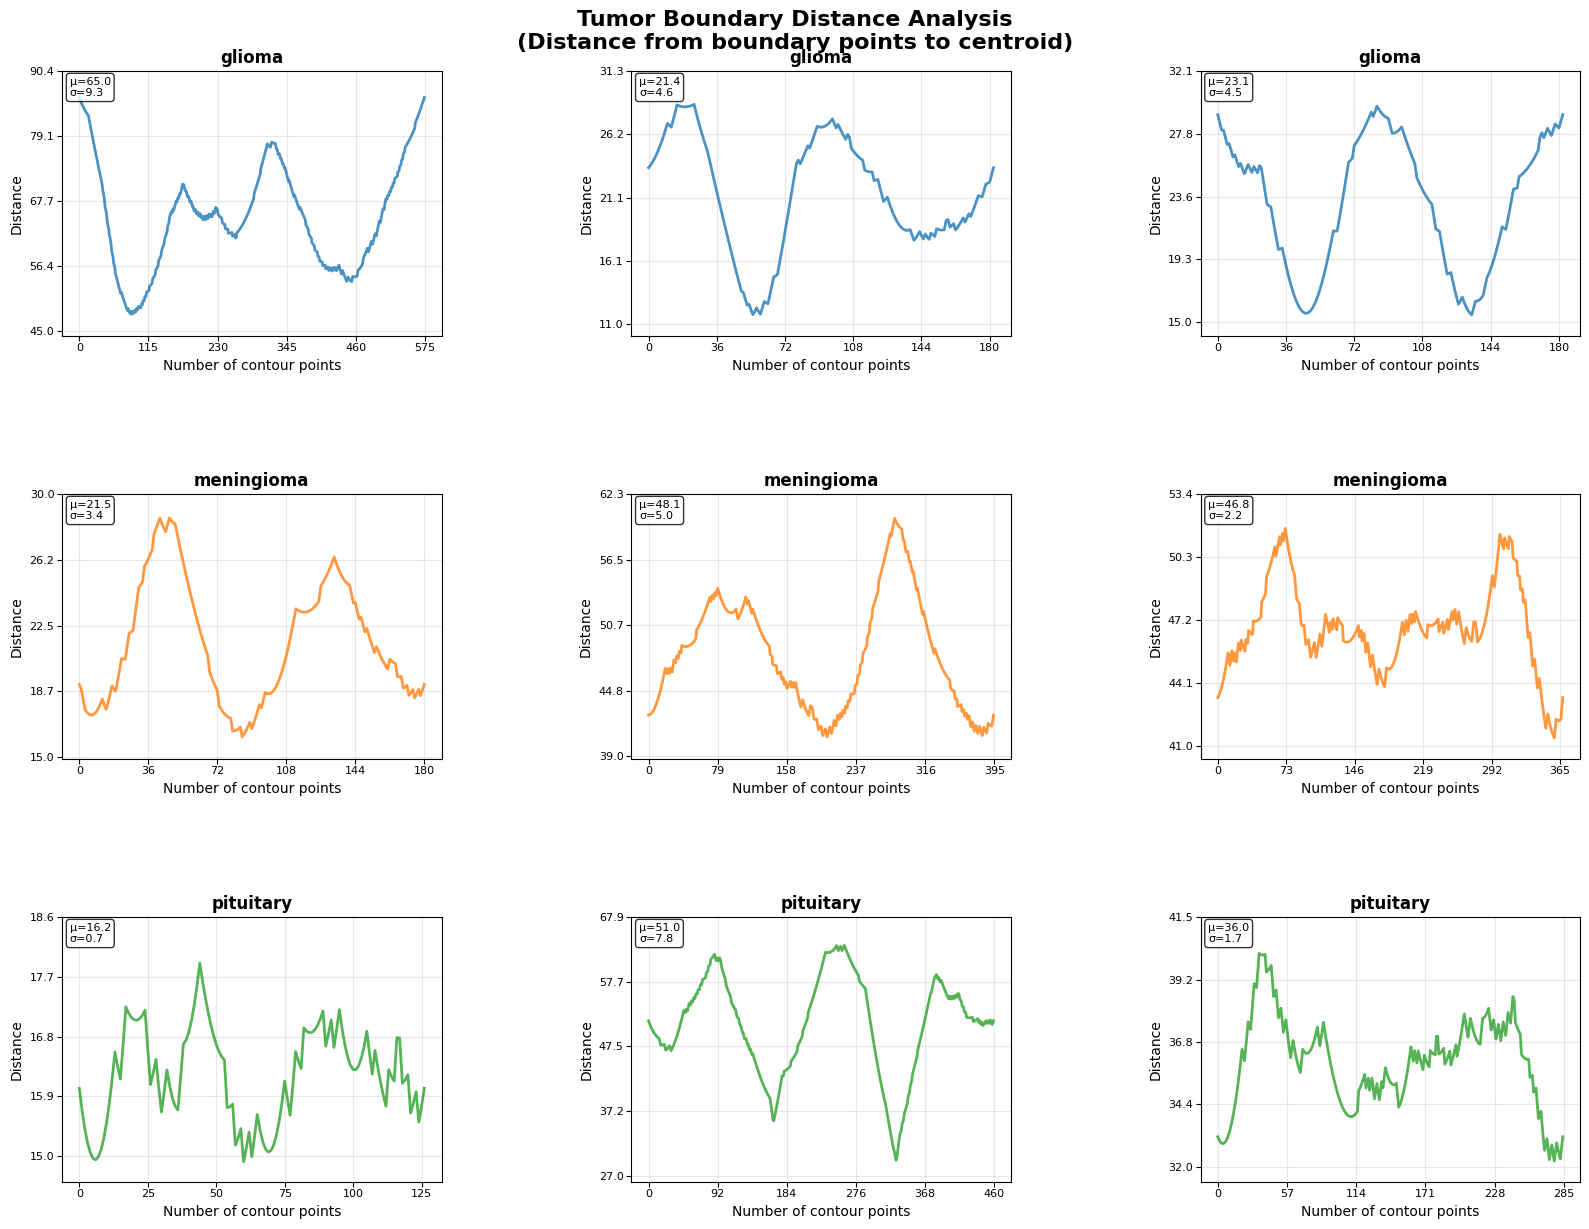

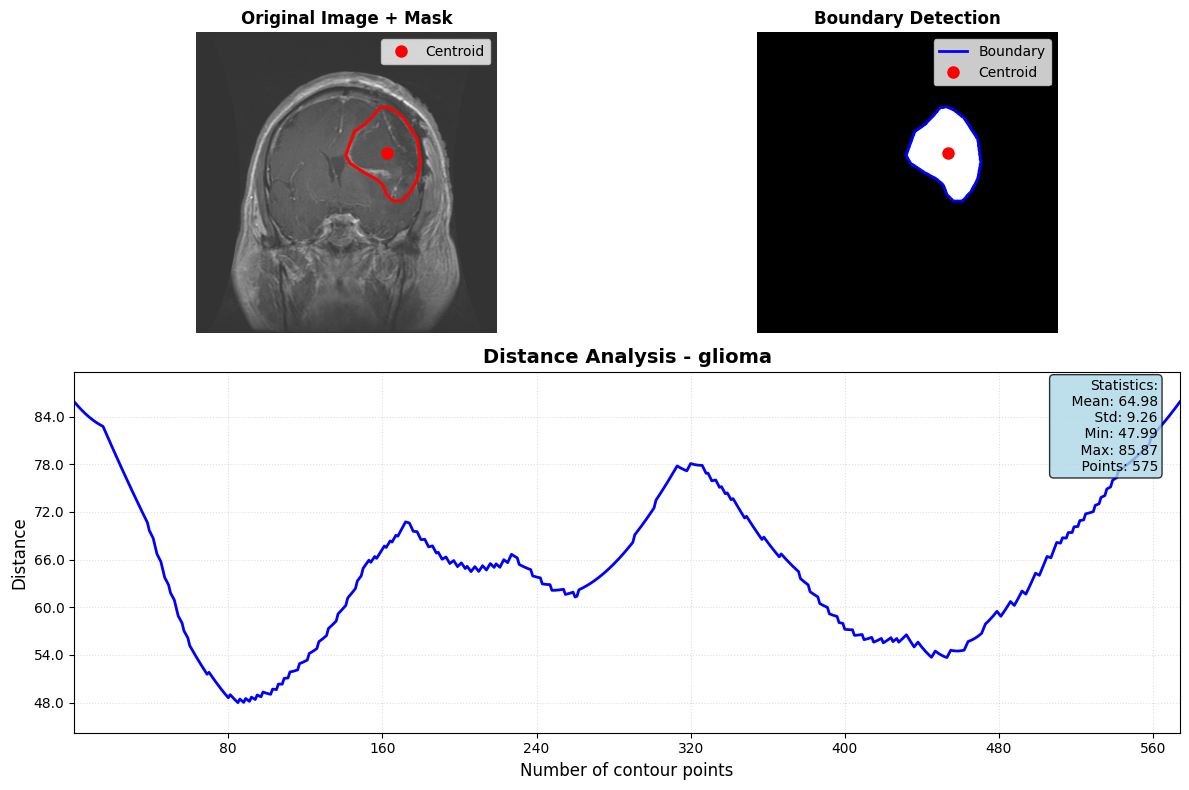

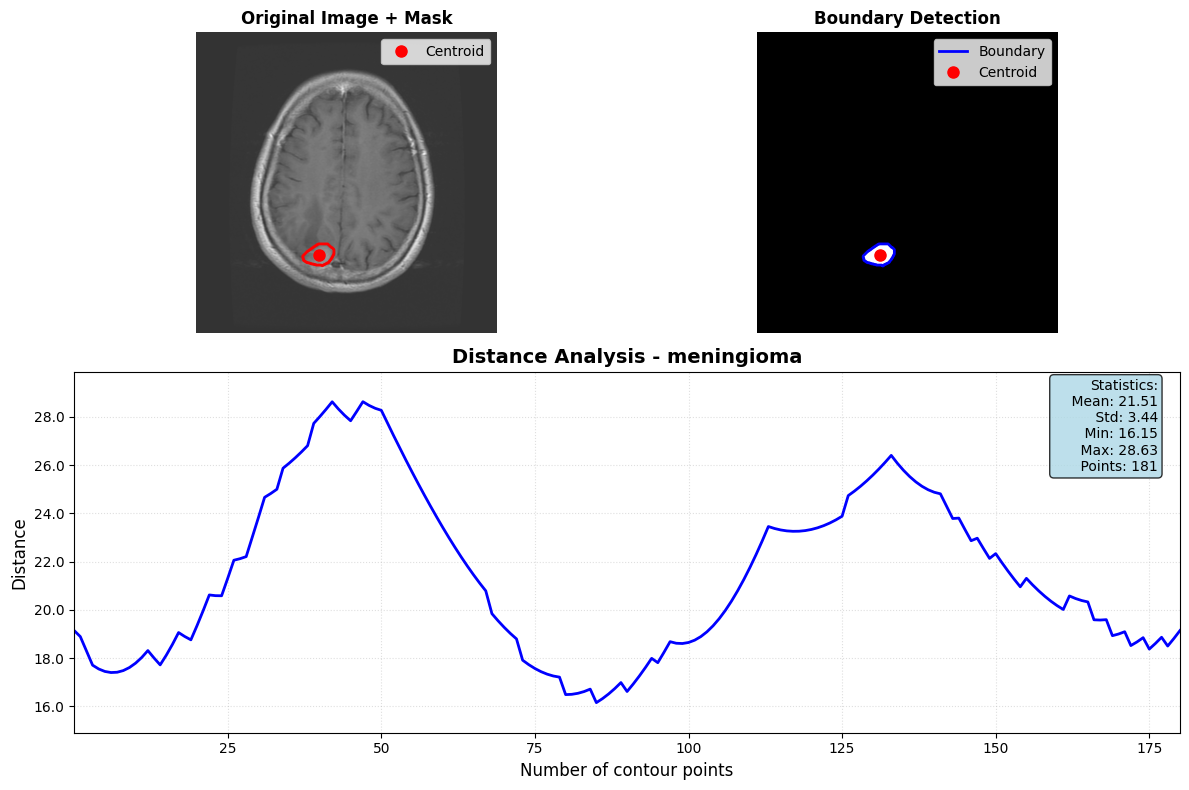

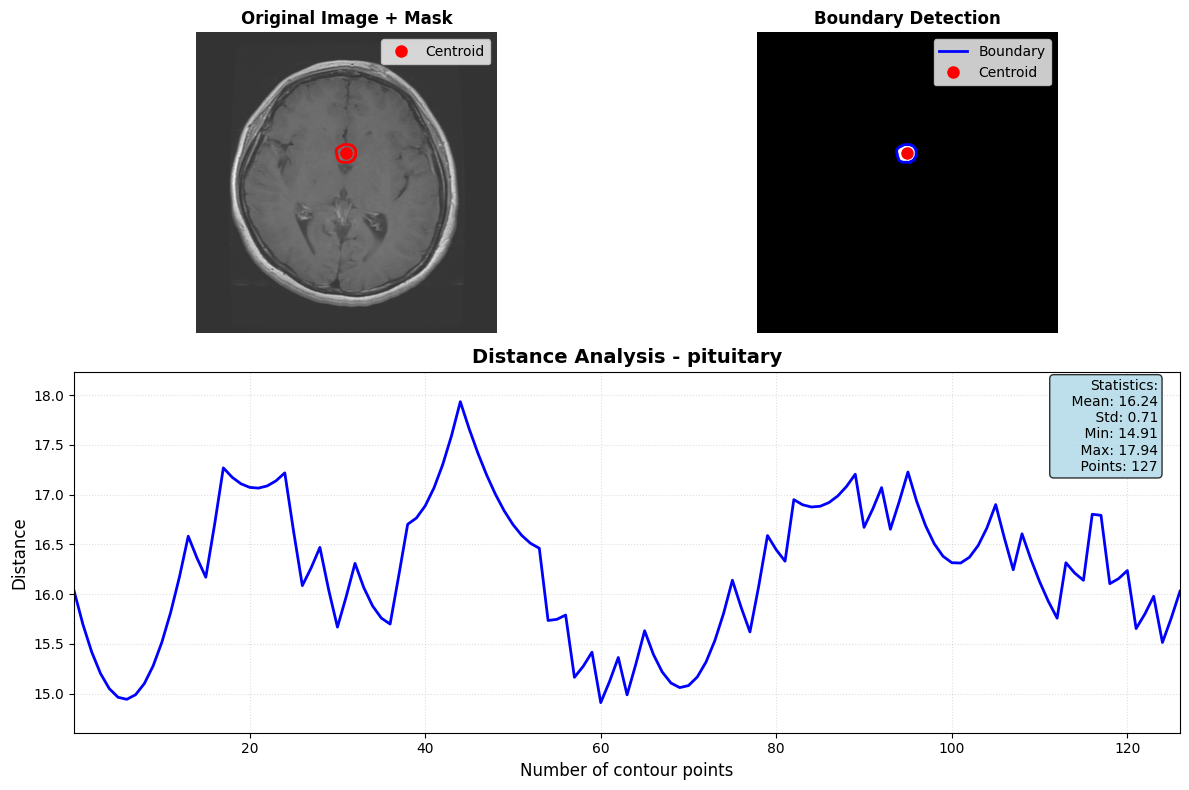


BOUNDARY ANALYSIS SUMMARY

GLIOMA:
  Average distance: 48.36 ± 22.24
  Distance range: 11.73 - 85.87
  Total boundary points: 941

MENINGIOMA:
  Average distance: 42.50 ± 10.92
  Distance range: 16.15 - 60.19
  Total boundary points: 945

PITUITARY:
  Average distance: 41.02 ± 13.53
  Distance range: 14.91 - 63.50
  Total boundary points: 873


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import random
import os
import glob
from skimage.measure import regionprops, find_contours
from skimage import io
import seaborn as sns
from matplotlib.ticker import MaxNLocator

def load_random_tumor_samples(dataset_folder, n_samples_per_class=3):
    """
    Load random samples from each tumor class folder

    Args:
        dataset_folder: path to Brain_Dataset folder containing glioma, meningioma, pituitary folders
        n_samples_per_class: number of random samples to load per class

    Returns:
        tumor_data_list: list of tumor data dictionaries
        class_labels: list of class names for each sample
    """
    class_names = ['glioma', 'meningioma', 'pituitary']
    tumor_data_list = []
    class_labels = []

    for class_name in class_names:
        class_folder = os.path.join(dataset_folder, class_name)

        if not os.path.exists(class_folder):
            print(f"Warning: Folder {class_folder} not found!")
            continue

        # Find all image files
        image_files = glob.glob(os.path.join(class_folder, "*_image.png"))

        if len(image_files) == 0:
            print(f"Warning: No image files found in {class_folder}")
            continue

        # Randomly select samples
        n_to_select = min(n_samples_per_class, len(image_files))
        selected_files = random.sample(image_files, n_to_select)

        for image_path in selected_files:
            # Get corresponding mask file
            base_name = os.path.basename(image_path).replace('_image.png', '')
            mask_path = os.path.join(class_folder, f"{base_name}_mask.png")

            if not os.path.exists(mask_path):
                print(f"Warning: Mask file {mask_path} not found!")
                continue

            try:
                # Load image and mask
                image = io.imread(image_path)
                mask = io.imread(mask_path)

                # Convert to appropriate types
                if len(image.shape) == 3:  # RGB image
                    image = np.mean(image, axis=2)  # Convert to grayscale
                image = image.astype(np.float64)

                # Handle mask processing
                if len(mask.shape) == 3:  # RGB mask
                    mask = np.mean(mask, axis=2)  # Convert to grayscale

                # For binary masks, use any non-zero threshold
                mask = (mask > 0).astype(bool)

                # Skip if mask is empty
                if not np.any(mask):
                    print(f"Warning: Empty mask for {image_path}")
                    continue

                # Calculate mask properties
                mask_props = regionprops(mask.astype(int))
                if not mask_props:
                    print(f"Warning: No regions found in mask for {image_path}")
                    continue

                props = mask_props[0]  # Take the largest region
                centroid = props.centroid
                bbox = props.bbox

                # Find boundaries
                contours = find_contours(mask, 0.5)
                if contours:
                    # Take the longest contour (main tumor boundary)
                    boundary = max(contours, key=len)
                else:
                    boundary = np.array([[centroid[0], centroid[1]]])

                # Create time series (distance from boundary points to centroid)
                time_series = np.sqrt(np.sum((boundary - np.array([centroid[0], centroid[1]]))**2, axis=1))

                tumor_data = {
                    'image': image,
                    'mask': mask,
                    'centroid': centroid,
                    'boundary': boundary,
                    'time_series': time_series,
                    'bbox': bbox,
                    'class_name': class_name,
                    'sample_id': base_name
                }

                tumor_data_list.append(tumor_data)
                class_labels.append(class_name)

                print(f"Loaded {class_name}: {base_name}")

            except Exception as e:
                print(f"Error loading {image_path}: {str(e)}")
                continue

    return tumor_data_list, class_labels

def plot_tumor_boundary_distances(tumor_data_list, class_labels, n_samples_per_class=3, figsize=(16, 12)):
    """
    Plot distance from boundary points to centroid for random samples from each tumor class

    Args:
        tumor_data_list: list of tumor data dictionaries
        class_labels: list of class names for each sample
        n_samples_per_class: number of random samples to plot per class
        figsize: figure size tuple
    """
    # Set style
    plt.style.use('default')
    sns.set_palette("husl")

    # Get unique class names and organize data
    class_names = ['glioma', 'meningioma', 'pituitary']
    class_samples = {class_name: [] for class_name in class_names}

    for tumor_data, class_label in zip(tumor_data_list, class_labels):
        if class_label in class_samples:
            class_samples[class_label].append(tumor_data)

    # Calculate subplot layout
    total_plots = len(class_names) * n_samples_per_class
    cols = n_samples_per_class
    rows = len(class_names)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        axes = axes.reshape(1, -1)
    if cols == 1:
        axes = axes.reshape(-1, 1)

    # Color map for classes
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    plot_idx = 0
    for class_idx, class_name in enumerate(class_names):
        # Get available samples from this class
        available_samples = class_samples[class_name]
        if len(available_samples) == 0:
            print(f"Warning: No samples found for class {class_name}")
            continue

        # Take the first n_samples_per_class (they're already randomly selected)
        selected_samples = available_samples[:n_samples_per_class]

        for sample_idx, tumor_data in enumerate(selected_samples):
            row = class_idx
            col = sample_idx
            ax = axes[row, col]

            # Get the time series (distance from boundary points to centroid)
            time_series = tumor_data['time_series']

            # Create x-axis (contour point indices)
            x_points = np.arange(len(time_series))

            # Plot the distance curve
            ax.plot(x_points, time_series,
                   color=colors[class_idx % len(colors)],
                   linewidth=2,
                   alpha=0.8)

            # Customize the plot
            ax.set_xlabel('Number of contour points', fontsize=10)
            ax.set_ylabel('Distance', fontsize=10)
            ax.set_title(f'{class_name}',
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)

            # Set y-axis limits for better visualization
            y_min, y_max = np.min(time_series), np.max(time_series)
            y_range = y_max - y_min
            ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)

            # Fix axis formatting for better readability
            ax.tick_params(axis='both', which='major', labelsize=9)

            # Format x-axis ticks to avoid overcrowding - logical integers only
            n_points = len(time_series)
            max_ticks = 5  # Maximum number of ticks
            if n_points <= max_ticks:
                x_ticks = np.arange(0, n_points)
            else:
                step = max(1, n_points // max_ticks)
                x_ticks = np.arange(0, n_points + 1, step)
                # Ensure we don't exceed the actual number of points
                x_ticks = x_ticks[x_ticks <= n_points]
            ax.set_xticks(x_ticks)

            # Format y-axis ticks to avoid overcrowding
            y_min, y_max = ax.get_ylim()
            y_range = y_max - y_min
            step_size = y_range / 4  # 4-5 ticks on y-axis
            y_ticks = np.arange(np.ceil(y_min), y_max + step_size, step_size)
            ax.set_yticks(y_ticks[:5])  # Maximum 5 ticks

            # Format both axes with clean numbers
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))

            # Ensure no overlap by adjusting tick parameters
            ax.tick_params(axis='x', labelsize=8, pad=2)
            ax.tick_params(axis='y', labelsize=8, pad=2)

            # Add some statistics as text
            mean_dist = np.mean(time_series)
            std_dist = np.std(time_series)
            ax.text(0.02, 0.98, f'μ={mean_dist:.1f}\nσ={std_dist:.1f}',
                   transform=ax.transAxes,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                   fontsize=8)

    # Hide empty subplots
    for class_idx, class_name in enumerate(class_names):
        available_samples = class_samples[class_name]
        n_available = len(available_samples)
        if n_available < n_samples_per_class:
            for col in range(n_available, n_samples_per_class):
                axes[class_idx, col].set_visible(False)

    plt.tight_layout()
    plt.suptitle('Tumor Boundary Distance Analysis\n(Distance from boundary points to centroid)',
                 fontsize=16, fontweight='bold', y=1.02)

    # Adjust layout to prevent axis label overlap - more spacing
    plt.subplots_adjust(hspace=0.6, wspace=0.5)

    return fig

# --- CHANGE 2: Replaced the entire function with this corrected version ---
def plot_single_tumor_analysis(tumor_data, class_name, figsize=(12, 8)):
    """
    Create a detailed analysis plot for a single tumor showing:
    1. Original image with mask overlay
    2. Boundary detection
    3. Distance plot
    4. Feature statistics
    """
    # Use GridSpec for a robust and clean layout, avoiding subplot overlap
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2]) # Give more height to the bottom plot

    # 1. Original image with mask overlay (top-left)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(tumor_data['image'], cmap='gray', alpha=0.8)
    ax1.contour(tumor_data['mask'], colors='red', linewidths=2)
    ax1.plot(tumor_data['centroid'][1], tumor_data['centroid'][0], 'ro', markersize=8, label='Centroid')
    ax1.set_title('Original Image + Mask', fontweight='bold')
    ax1.axis('off')
    ax1.legend()

    # 2. Boundary points (top-right)
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(tumor_data['mask'], cmap='gray')
    boundary = tumor_data['boundary']
    ax2.plot(boundary[:, 1], boundary[:, 0], 'b-', linewidth=2, label='Boundary')
    ax2.plot(tumor_data['centroid'][1], tumor_data['centroid'][0], 'ro', markersize=8, label='Centroid')
    ax2.set_title('Boundary Detection', fontweight='bold')
    ax2.axis('off')
    ax2.legend()

    # 3. Distance plot (spanning the entire bottom row)
    ax3 = fig.add_subplot(gs[1, :])
    time_series = tumor_data['time_series']
    x_points = np.arange(len(time_series))

    ax3.plot(x_points, time_series, 'b-', linewidth=2)
    ax3.set_xlabel('Number of contour points', fontsize=12)
    ax3.set_ylabel('Distance', fontsize=12)
    ax3.set_title(f'Distance Analysis - {class_name}', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.4, linestyle=':')

    # Set logical axis limits before setting ticks
    y_min, y_max = np.min(time_series), np.max(time_series)
    y_range = y_max - y_min
    ax3.set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)
    ax3.set_xlim(0, len(time_series) - 1)

    # Use MaxNLocator for clean, non-overlapping ticks
    ax3.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True, prune='both'))
    ax3.yaxis.set_major_locator(MaxNLocator(nbins=8))

    # Set a clean format for the y-axis ticks
    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))

    # Add statistics box
    stats_text = f"""Statistics:
    Mean: {np.mean(time_series):.2f}
    Std: {np.std(time_series):.2f}
    Min: {np.min(time_series):.2f}
    Max: {np.max(time_series):.2f}
    Points: {len(time_series)}"""

    ax3.text(0.98, 0.98, stats_text,
            transform=ax3.transAxes,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8),
            fontsize=10)

    # Use tight_layout to adjust spacing between plots
    plt.tight_layout()
    return fig

def create_comparison_plots(dataset_folder, n_samples_per_class=3):
    """
    Main function to create comparison plots directly from the dataset folder

    Args:
        dataset_folder: path to Brain_Dataset folder containing subfolders (glioma, meningioma, pituitary)
        n_samples_per_class: number of random samples to analyze per class
    """

    print(f"Loading random samples from dataset folder: {dataset_folder}")
    print(f"Samples per class: {n_samples_per_class}")

    # Load random tumor samples directly from folders
    tumor_data_list, class_labels = load_random_tumor_samples(dataset_folder, n_samples_per_class)

    if len(tumor_data_list) == 0:
        print("No data loaded! Please check your dataset path and folder structure.")
        print("Expected structure:")
        print("  Brain_Dataset/")
        print("  ├── glioma/")
        print("  │   ├── sample1_image.png")
        print("  │   ├── sample1_mask.png")
        print("  │   └── ...")
        print("  ├── meningioma/")
        print("  │   └── ...")
        print("  └── pituitary/")
        print("      └── ...")
        return

    print(f"\nDataset loaded successfully!")
    print(f"Total samples: {len(tumor_data_list)}")

    # Count samples per class
    class_counts = {}
    for class_label in class_labels:
        class_counts[class_label] = class_counts.get(class_label, 0) + 1

    print("Samples per class:")
    for class_name, count in class_counts.items():
        print(f"  {class_name}: {count} samples")

    # Create the multi-class comparison plot
    print("\nCreating comparison plots...")
    fig1 = plot_tumor_boundary_distances(tumor_data_list, class_labels, n_samples_per_class)

    # Save the comparison plot
    fig1.savefig('tumor_boundary_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Comparison plot saved as 'tumor_boundary_comparison.png'")

    # Create detailed single tumor analysis for one example from each class
    print("Creating detailed analysis plots...")
    class_samples = {}
    for tumor_data, class_label in zip(tumor_data_list, class_labels):
        if class_label not in class_samples:
            class_samples[class_label] = []
        class_samples[class_label].append(tumor_data)

    for class_name, samples in class_samples.items():
        if samples:
            # Take the first sample from this class
            tumor_data = samples[0]

            fig2 = plot_single_tumor_analysis(tumor_data, class_name)
            filename = f'detailed_analysis_{class_name.lower()}.png'
            fig2.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"✓ Detailed analysis for {class_name} saved as '{filename}'")

    plt.show()

    # Print summary statistics
    print("\n" + "="*60)
    print("BOUNDARY ANALYSIS SUMMARY")
    print("="*60)

    for class_name in ['glioma', 'meningioma', 'pituitary']:
        class_distances = []
        for tumor_data, class_label in zip(tumor_data_list, class_labels):
            if class_label == class_name:
                class_distances.extend(tumor_data['time_series'])

        if class_distances:
            print(f"\n{class_name.upper()}:")
            print(f"  Average distance: {np.mean(class_distances):.2f} ± {np.std(class_distances):.2f}")
            print(f"  Distance range: {np.min(class_distances):.2f} - {np.max(class_distances):.2f}")
            print(f"  Total boundary points: {len(class_distances)}")

# Example usage
if __name__ == "__main__":
    # Set your dataset path - UPDATE THIS PATH TO YOUR ACTUAL DATASET LOCATION
    dataset_folder = "    "  # Update this path
    # Alternative examples:
    # dataset_folder = "C:/path/to/your/Brain_Dataset"  # Windows
    # dataset_folder = "/home/user/Brain_Dataset"       # Linux
    # dataset_folder = "/Users/username/Brain_Dataset"  # Mac

    # Set random seed for reproducible results
    random.seed(42)
    np.random.seed(42)

    # Create the plots - you can change n_samples_per_class to get more/fewer samples
    create_comparison_plots(dataset_folder, n_samples_per_class=3)

    # Alternative: Create plots with different number of samples per class
    # create_comparison_plots(dataset_folder, n_samples_per_class=5)  # 5 samples per class

In [ ]:
import numpy as np
import os
import glob
from scipy.io import loadmat
from skimage.measure import regionprops, find_contours
from skimage.morphology import binary_erosion
from skimage import io
import pandas as pd
from itertools import permutations

class TumorFeatureExtractor:
    def __init__(self):
        self.dim = 1  # embedding dimension
        self.r = 0.2  # tolerance for entropy calculations
        self.uniform_intervals = 128
        self.Kmax = 4  # maximum number of sub-series for Higuchi fractal

    def diagnose_masks(self, dataset_folder, num_samples=5):
       
        print("=== MASK DIAGNOSIS ===")
        class_names = ['glioma', 'meningioma', 'pituitary']

        for class_name in class_names:
            class_folder = os.path.join(dataset_folder, class_name)
            if not os.path.exists(class_folder):
                continue

            print(f"\n📁 Checking {class_name} masks...")
            image_files = glob.glob(os.path.join(class_folder, "*_image.png"))[:num_samples]

            for image_path in image_files:
                base_name = os.path.basename(image_path).replace('_image.png', '')
                mask_path = os.path.join(class_folder, f"{base_name}_mask.png")

                if os.path.exists(mask_path):
                    try:
                        mask = io.imread(mask_path)
                        print(f"  {base_name}:")
                        print(f"    Shape: {mask.shape}")
                        print(f"    Data type: {mask.dtype}")
                        print(f"    Min value: {np.min(mask)}")
                        print(f"    Max value: {np.max(mask)}")
                        print(f"    Unique values: {np.unique(mask)}")
                        print(f"    Non-zero pixels: {np.sum(mask > 0)}/{mask.size}")

                        # Test different thresholds
                        thresh_results = []
                        for thresh in [0, 1, 50, 100, 128, 200, 255]:
                            count = np.sum(mask > thresh)
                            thresh_results.append(f">{thresh}: {count}")
                        print(f"    Threshold tests: {', '.join(thresh_results)}")

                    except Exception as e:
                        print(f"  {base_name}: Error reading mask - {e}")

        print("\n=== END DIAGNOSIS ===\n")

    def load_tumor_data(self, dataset_folder, diagnose=False):
        """
        Load tumor data from Brain_Dataset folder structure

        Args:
            dataset_folder: path to Brain_Dataset folder containing glioma, meningioma, pituitary folders
            diagnose: if True, run mask diagnosis first

        Returns:
            tumor_images: list of dictionaries containing image data
            labels: list of labels (0=glioma, 1=meningioma, 2=pituitary)
            class_names: list of class names
        """
        if diagnose:
            self.diagnose_masks(dataset_folder)

        tumor_images = []
        labels = []
        class_names = ['glioma', 'meningioma', 'pituitary']

        for class_idx, class_name in enumerate(class_names):
            class_folder = os.path.join(dataset_folder, class_name)

            if not os.path.exists(class_folder):
                print(f"Warning: Folder {class_folder} not found!")
                continue

            # Find all image files
            image_files = glob.glob(os.path.join(class_folder, "*_image.png"))

            for image_path in image_files:
                # Get corresponding mask file
                base_name = os.path.basename(image_path).replace('_image.png', '')
                mask_path = os.path.join(class_folder, f"{base_name}_mask.png")

                if not os.path.exists(mask_path):
                    print(f"Warning: Mask file {mask_path} not found!")
                    continue

                try:
                    # Load image and mask
                    image = io.imread(image_path)
                    mask = io.imread(mask_path)

                    # Convert to appropriate types
                    if len(image.shape) == 3:  # RGB image
                        image = np.mean(image, axis=2)  # Convert to grayscale
                    image = image.astype(np.float64)

                    # Handle mask processing - optimized for binary (0,1) masks
                    if len(mask.shape) == 3:  # RGB mask
                        mask = np.mean(mask, axis=2)  # Convert to grayscale

                    # For binary masks (0,1), use any non-zero threshold
                    mask = (mask > 0).astype(bool)

                    if not np.any(mask):
                        print(f"Warning: Empty mask for {image_path}")
                        continue

                    # Calculate mask properties
                    mask_props = regionprops(mask.astype(int))
                    if not mask_props:
                        print(f"Warning: No regions found in mask for {image_path}")
                        continue

                    props = mask_props[0]  # Take the largest region
                    centroid = props.centroid
                    bbox = props.bbox

                    # Find boundaries
                    contours = find_contours(mask, 0.5)
                    if contours:
                        # Take the longest contour (main tumor boundary)
                        boundary = max(contours, key=len)
                    else:
                        boundary = np.array([[centroid[0], centroid[1]]])

                    # Create time series (distance from boundary points to centroid)
                    time_series = np.sqrt(np.sum((boundary - np.array([centroid[0], centroid[1]]))**2, axis=1))

                    tumor_data = {
                        'image': image,
                        'mask': mask,
                        'centroid': centroid,
                        'boundary': boundary,
                        'time_series': time_series,
                        'bbox': bbox,
                        'class_name': class_name,
                        'sample_id': base_name
                    }

                    tumor_images.append(tumor_data)
                    labels.append(class_idx)

                    print(f"Loaded {class_name}: {base_name}")

                except Exception as e:
                    print(f"Error loading {image_path}: {str(e)}")
                    continue

        return tumor_images, labels, class_names

    def lyapunov_exponent(self, x, dt=1):
        """
        Calculate Lyapunov exponents from time series
        """
        x = np.array(x).reshape(-1, 1) if len(np.array(x).shape) == 1 else np.array(x)
        ndata = x.shape[0]

        if ndata < 10:
            return 0, [0, 0, 0, 0]

        N2 = ndata // 2
        N4 = ndata // 4
        TOL = 1.0e-6

        exponent = np.zeros(N4 + 1)

        for i in range(N4, N2):  # second quartile of data
            dist = np.linalg.norm(x[i+1, :] - x[i, :])
            indx = i + 1

            for j in range(ndata - 5):
                if i != j and np.linalg.norm(x[i, :] - x[j, :]) < dist:
                    dist = np.linalg.norm(x[i, :] - x[j, :])
                    indx = j  # closest point

            expn = 0.0  # estimate local rate of expansion
            for k in range(1, 6):
                if (i + k < ndata and indx + k < ndata and
                    np.linalg.norm(x[i+k, :] - x[indx+k, :]) > TOL and
                    np.linalg.norm(x[i, :] - x[indx, :]) > TOL):
                    expn += (np.log(np.linalg.norm(x[i+k, :] - x[indx+k, :])) -
                            np.log(np.linalg.norm(x[i, :] - x[indx, :]))) / k

            exponent[i - N4] = expn / 5

        lam = np.mean(exponent) / dt
        exponent_sorted = np.sort(exponent)[::-1]  # sort from max to min

        # Return first 4 exponents
        if len(exponent_sorted) >= 4:
            return lam, exponent_sorted[:4].tolist()
        else:
            padded = list(exponent_sorted) + [0] * (4 - len(exponent_sorted))
            return lam, padded

    def higuchi_fractal_dimension(self, serie, Kmax):
        N = len(serie)
        L = np.zeros(Kmax)

        for k in range(1, Kmax + 1):
            L_m = np.zeros(k)
            for m in range(1, k + 1):
                limit = (N - m) // k
                if limit <= 0:
                    continue

                # Extract subsequence
                indices = np.arange(m - 1, m - 1 + (limit + 1) * k, k)
                indices = indices[indices < N]
                aux = serie[indices]

                if len(aux) <= 1:
                    continue

                # Calculate length
                L_m_val = np.sum(np.abs(np.diff(aux)))
                R = (N - 1) / (limit * k)
                L_m[m - 1] = (L_m_val * R) / k

            L[k - 1] = np.mean(L_m)

        # Linear regression to find slope
        x = 1.0 / np.arange(1, Kmax + 1)
        valid_idx = L > 0
        if np.sum(valid_idx) < 2:
            return 0

        coeffs = np.polyfit(np.log(x[valid_idx]), np.log(L[valid_idx]), 1)
        return coeffs[0]

    def katz_fractal_dimension(self, serie):

        N = len(serie)
        if N < 2:
            return 0

        n = N - 1  # number of steps

        # Computing 'L' (total length)
        L = 0
        for i in range(N - 1):
            aux = np.sqrt(1 + (serie[i] - serie[i + 1])**2)
            L += aux

        if L == 0:
            return 0

        # Computing 'd' (diameter)
        dist = np.zeros(N - 1)
        for i in range(1, N):
            dist[i - 1] = np.sqrt(((1 - (i + 1))**2) + ((serie[0] - serie[i])**2))

        d = np.max(dist)

        if d == 0:
            return 0

        # Computing KFD
        KFD = np.log10(n) / (np.log10(n) + np.log10(d / L))
        return KFD

    def box_counting_fractal_dimension(self, sig):
  
        # Normalization
        sig = (sig - np.mean(sig)) / np.std(sig)
        sig = (sig > 0).astype(int)  # Convert to binary

        if sig.ndim > 1:
            sig = sig.flatten()

        width = len(sig)
        p = int(np.ceil(np.log2(width)))
        width = 2**p

        # Pad signal to power of 2 length
        mz = np.zeros(width)
        mz[:len(sig)] = sig
        sig = mz.astype(bool)

        n = np.zeros(p + 1)
        n[p] = np.sum(sig)

        for g in range(p - 1, -1, -1):
            siz = 2**(p - g)
            siz2 = siz // 2

            for i in range(0, width - siz + 1, siz):
                if i + siz2 < len(sig):
                    sig[i] = sig[i] or sig[i + siz2]

            indices = np.arange(0, width - siz + 1, siz)
            indices = indices[indices < len(sig)]
            n[g] = np.sum(sig[indices])

        n = n[::-1]  # Reverse array
        r = 2.0**np.arange(p + 1)

        if len(n) < 2:
            return 0

        df = -np.diff(np.log(n + 1e-10)) / np.diff(np.log(r + 1e-10))

        # Use indices 3:7 (equivalent to MATLAB 4:8)
        start_idx = min(3, len(df))
        end_idx = min(8, len(df))

        if start_idx >= end_idx:
            return np.mean(df) if len(df) > 0 else 0

        return np.mean(df[start_idx:end_idx])

    def petrosian_fractal_dimension(self, sig, w=None):

        if w is None:
            w = len(sig) - 1

        # Normalization
        sig = (sig - np.mean(sig)) / np.std(sig)
        N = len(sig)

        if N <= w:
            return 0

        PFD_values = np.zeros(N - w)

        for j in range(N - w):
            x1 = sig[j:j + w]
            Bs = np.zeros(w - 1)

            for i in range(w - 1):
                if x1[i + 1] >= x1[i]:
                    Bs[i] = 1
                else:
                    Bs[i] = -1

            Nd = 0
            for i in range(w - 2):
                if (Bs[i + 1] - Bs[i]) != 0:
                    Nd += 1

            if w - 1 + 0.4 * Nd == 0:
                PFD_values[j] = 0
            else:
                PFD_values[j] = np.log10(w - 1) / (np.log10(w - 1) + np.log10((w - 1) / ((w - 1) + 0.4 * Nd)))

        return np.mean(PFD_values)

    def approximate_entropy(self, series, dim, r):
  
        N = len(series)
        result = np.zeros(2)
        r_scaled = r * np.std(series)

        for j in range(2):
            m = dim + j
            phi = np.zeros(N - m + 1)

            if m == 1:
                patterns = series.reshape(1, -1)
            else:
                patterns = np.zeros((m, N - m + 1))
                for i in range(m):
                    patterns[i, :] = series[i:N - m + i + 1]

            for i in range(N - m + 1):
                if m == 1:
                    temp = np.abs(patterns - patterns[:, i:i+1])
                else:
                    temp = np.max(np.abs(patterns - patterns[:, i:i+1]), axis=0)

                bool_mask = temp < r_scaled
                phi[i] = np.sum(bool_mask) / (N - m + 1)

            result[j] = np.mean(np.log(phi + 1e-10))

        ApEn = result[0] - result[1]
        return ApEn

    def permutation_entropy(self, series, L):
       
        N = len(series)

        if N < L:
            return 0

        # Create patterns matrix
        X = np.zeros((L, N - L + 1))
        for j in range(L):
            if j == 0:
                X[j, :] = series[:N - L + 1]
            else:
                X[j, :N - L + 1 - j] = series[j:N - j]

        # Get permutation vectors
        perm = np.full((N - L + 1, L), np.nan)

        for j in range(N - L + 1):
            Y = X[:, j]
            Z = np.sort(Y)
            aux = np.zeros(L)

            for i in range(L):
                if i == 0:
                    aux[i] = np.where(Y == Z[i])[0][0]
                else:
                    if Z[i] == Z[i - 1]:
                        aux[i] = aux[i - 1] + 1
                    else:
                        aux[i] = np.where(Y == Z[i])[0][0]

            perm[j, :] = aux

        # Count unique permutations
        num = np.zeros(N - L + 1)

        for j in range(N - L + 1):
            if np.any(np.isnan(perm[j, :])):
                continue

            num[j] += 1
            for i in range(j + 1, N - L + 1):
                if not np.any(np.isnan(perm[i, :])) and np.array_equal(perm[j, :], perm[i, :]):
                    num[j] += 1
                    perm[i, :] = np.nan

        # Calculate entropy
        num = num / (N - L + 1)
        num_nonzero = num[num != 0]

        if len(num_nonzero) == 0:
            return 0

        PermEn = -np.sum(num_nonzero * np.log(num_nonzero))
        return PermEn

    def sample_entropy(self, series, dim, r):
    
        # Normalization
        series = (series - np.mean(series)) / np.std(series)
        N = len(series)
        result = np.zeros(2)

        for j in range(2):
            m = dim + j
            count = np.zeros(N - m)

            if m == 1:
                patterns = series.reshape(1, -1)
            else:
                patterns = np.zeros((m, N - m + 1))
                for i in range(m):
                    patterns[i, :] = series[i:N - m + i + 1]

            for i in range(N - m):
                if m == 1:
                    temp = np.abs(patterns - patterns[:, i:i+1])
                else:
                    temp = np.max(np.abs(patterns - patterns[:, i:i+1]), axis=0)

                bool_mask = temp <= r
                count[i] = (np.sum(bool_mask) - 1) / (N - m - 1)  # Exclude self-match

            result[j] = np.mean(count)

        if result[1] == 0:
            return float('inf')

        SampEn = np.log(result[0] / result[1])
        return SampEn

    def extract_features(self, tumor_images, labels, class_names):
       
        n_samples = len(tumor_images)

        # Initialize feature arrays
        LyExp = np.zeros((n_samples, 4))
        HFD = np.zeros(n_samples)
        KFD = np.zeros(n_samples)
        BCD = np.zeros(n_samples)
        PFD = np.zeros(n_samples)
        ApEn = np.zeros(n_samples)
        PermEn = np.zeros(n_samples)
        SampEn = np.zeros(n_samples)

        sample_info = []

        for i, tumor_data in enumerate(tumor_images):
            print(f"Processing {tumor_data['class_name']} - {tumor_data['sample_id']} ({i+1}/{n_samples})...")

            # Extract tumor area pixels
            image = tumor_data['image']
            mask = tumor_data['mask']
            area_pixels_val = image[mask]

            # Skip if no tumor pixels
            if len(area_pixels_val) == 0:
                print(f"Warning: No tumor pixels found for {tumor_data['sample_id']}")
                continue

            try:
                # Lyapunov exponents
                max_exp, all_exp = self.lyapunov_exponent(tumor_data['time_series'])
                LyExp[i, :] = all_exp

                # Fractal Dimensions
                HFD[i] = self.higuchi_fractal_dimension(area_pixels_val, self.Kmax)
                KFD[i] = self.katz_fractal_dimension(area_pixels_val)
                BCD[i] = self.box_counting_fractal_dimension(area_pixels_val)
                PFD[i] = self.petrosian_fractal_dimension(area_pixels_val, 10)

                # Entropy measures
                ApEn[i] = self.approximate_entropy(area_pixels_val, self.dim, self.r)
                PermEn[i] = self.permutation_entropy(area_pixels_val, self.dim + 1)
                SampEn[i] = self.sample_entropy(area_pixels_val, self.dim, self.r)

                sample_info.append({
                    'class_name': tumor_data['class_name'],
                    'sample_id': tumor_data['sample_id'],
                    'label': labels[i]
                })

                print(f"✓ Features extracted for {tumor_data['sample_id']}")

            except Exception as e:
                print(f"Error extracting features for {tumor_data['sample_id']}: {str(e)}")
                # Fill with zeros for failed extractions
                sample_info.append({
                    'class_name': tumor_data['class_name'],
                    'sample_id': tumor_data['sample_id'],
                    'label': labels[i]
                })

        # Combine all features
        features = np.column_stack([LyExp, HFD, KFD, BCD, PFD, ApEn, PermEn, SampEn])

        feature_names = [
            'LyExp_1', 'LyExp_2', 'LyExp_3', 'LyExp_4',
            'Higuchi_FD', 'Katz_FD', 'BoxCounting_FD', 'Petrosian_FD',
            'Approximate_Entropy', 'Permutation_Entropy', 'Sample_Entropy'
        ]

        return features, feature_names, sample_info



def main():
 
    extractor = TumorFeatureExtractor()

    dataset_folder = "# Your dataset patht" 

    print("Loading brain tumor dataset...")
    # Load data (set diagnose=True if you want to see mask statistics)
    tumor_images, labels, class_names = extractor.load_tumor_data(dataset_folder, diagnose=False)

    print(f"\nDataset loaded successfully!")
    print(f"Total samples: {len(tumor_images)}")
    print(f"Classes: {class_names}")

    # Count samples per class
    for i, class_name in enumerate(class_names):
        count = sum(1 for label in labels if label == i)
        print(f"  {class_name}: {count} samples")

    if len(tumor_images) == 0:
        print("No data loaded!")
        return None, None, None

    print(f"\nExtracting features from {len(tumor_images)} samples...")
    # Extract features
    features, feature_names, sample_info = extractor.extract_features(tumor_images, labels, class_names)

    df = pd.DataFrame(features, columns=feature_names)

    for i, info in enumerate(sample_info):
        df.loc[i, 'class_name'] = info['class_name']
        df.loc[i, 'sample_id'] = info['sample_id']
        df.loc[i, 'label'] = info['label']

    cols = ['sample_id', 'class_name', 'label'] + feature_names
    df = df[cols]

    print("\n" + "="*60)
    print("FEATURE EXTRACTION COMPLETED!")
    print("="*60)
    print(f"Feature matrix shape: {features.shape}")
    print(f"Classes: {class_names}")
    print(f"Features: {feature_names}")
    print("\nDataset summary by class:")
    print(df.groupby('class_name').size())

    print("\nFirst few samples:")
    print(df.head())

    print(f"\nFeature statistics:")
    print(df[feature_names].describe())

    output_file = 'non_linear_features.csv'
    df.to_csv(output_file, index=False)
    print(f"\n✓ Features saved to '{output_file}'")

    summary_file = 'feature_summary.txt'
    with open(summary_file, 'w') as f:
        f.write("Brain Tumor Feature Extraction Summary\n")
        f.write("=====================================\n\n")
        f.write(f"Total samples: {len(tumor_images)}\n")
        f.write(f"Classes: {class_names}\n\n")
        f.write("Class distribution:\n")
        for class_name, count in df.groupby('class_name').size().items():
            f.write(f"  {class_name}: {count} samples\n")
        f.write(f"\nFeatures extracted: {len(feature_names)}\n")
        f.write("Feature list:\n")
        for i, feature in enumerate(feature_names, 1):
            f.write(f"  {i}. {feature}\n")

    print(f"✓ Summary saved to '{summary_file}'")

    return features, labels, feature_names, class_names, df


if __name__ == "__main__":
    features, labels, feature_names, class_names, df = main()


In [ ]:
import numpy as np
import os
import glob
import json
import csv
from scipy.interpolate import splprep, splev
from scipy import stats
from skimage.measure import regionprops, find_contours
from skimage import io
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import pdist, squareform

class InformationWeightedTumorTimeSeriesGenerator:
    """
    Enhanced tumor time series generator with information-weighted normalization
    """

    def __init__(self, target_points=256, upsampling_factor=4, smoothing_factor=0,
                 entropy_window=5, entropy_method='variance', weighting_strength=1.0):
        self.target_points = target_points
        self.upsampling_factor = upsampling_factor
        self.smoothing_factor = smoothing_factor
        self.min_boundary_points = 10

        # Information weighting parameters
        self.entropy_window = entropy_window  # Neighborhood size for local entropy calculation
        self.entropy_method = entropy_method  # 'variance', 'pattern_complexity', 'curvature_entropy'
        self.weighting_strength = weighting_strength  # How much to emphasize high-entropy regions

    def _upsample_mask(self, mask):
        """Increase mask resolution using high-quality interpolation"""
        if self.upsampling_factor <= 1:
            return mask

        mask_float = mask.astype(np.float32)
        new_height = mask.shape[0] * self.upsampling_factor
        new_width = mask.shape[1] * self.upsampling_factor

        upsampled = cv2.resize(mask_float, (new_width, new_height),
                              interpolation=cv2.INTER_CUBIC)

        return (upsampled > 0.5).astype(bool)

    def _validate_and_clean_boundary(self, boundary):
        """Enhanced validation and cleaning of boundary data before spline fitting"""

        # Convert to float64 for better numerical stability
        boundary = np.array(boundary, dtype=np.float64)

        # Remove any NaN or infinite values
        valid_indices = np.all(np.isfinite(boundary), axis=1)
        clean_boundary = boundary[valid_indices]

        if len(clean_boundary) < 4:
            print(f"Only {len(clean_boundary)} valid points found")
            return boundary  # Return original if too few valid points

        # Remove duplicate consecutive points with adaptive threshold
        # Calculate appropriate distance threshold based on boundary scale
        boundary_extent = max(np.ptp(clean_boundary[:, 0]), np.ptp(clean_boundary[:, 1]))
        min_distance = max(0.01, boundary_extent * 0.001)  # Adaptive threshold

        unique_boundary = [clean_boundary[0]]

        for i in range(1, len(clean_boundary)):
            distance = np.linalg.norm(clean_boundary[i] - unique_boundary[-1])
            if distance > min_distance:
                unique_boundary.append(clean_boundary[i])

        # Check if last point is too close to first point (for closed contour)
        if len(unique_boundary) > 1:
            dist_to_first = np.linalg.norm(unique_boundary[-1] - unique_boundary[0])
            if dist_to_first < min_distance:
                unique_boundary = unique_boundary[:-1]

        unique_boundary = np.array(unique_boundary)

        # Ensure we still have enough points
        if len(unique_boundary) < 4:
            print(f"After deduplication: only {len(unique_boundary)} points remain")
            # Try with less aggressive deduplication
            min_distance = min_distance * 0.1
            unique_boundary = [clean_boundary[0]]
            for i in range(1, len(clean_boundary)):
                distance = np.linalg.norm(clean_boundary[i] - unique_boundary[-1])
                if distance > min_distance:
                    unique_boundary.append(clean_boundary[i])
            unique_boundary = np.array(unique_boundary)

            if len(unique_boundary) < 4:
                return boundary  # Return original

        # Check for degenerate cases (all points in a line or very small area)
        if len(unique_boundary) >= 3:
            # Calculate area using shoelace formula
            x = unique_boundary[:, 0]
            y = unique_boundary[:, 1]
            area = 0.5 * abs(sum(x[i] * y[i+1] - x[i+1] * y[i] for i in range(-1, len(x)-1)))

            # Use relative area threshold based on boundary size
            perimeter_approx = np.sum(np.sqrt(np.sum(np.diff(unique_boundary, axis=0)**2, axis=1)))
            area_threshold = (perimeter_approx ** 2) * 0.001  # Adaptive threshold

            if area < area_threshold:
                print(f"Degenerate boundary detected (area: {area:.6f}, threshold: {area_threshold:.6f})")
                return boundary  # Return original

        # Additional check: ensure points aren't all on a grid line
        x_unique = len(np.unique(np.round(unique_boundary[:, 0], decimals=6)))
        y_unique = len(np.unique(np.round(unique_boundary[:, 1], decimals=6)))

        if x_unique < 2 or y_unique < 2:
            print(f"Boundary points are colinear (x_unique: {x_unique}, y_unique: {y_unique})")
            return boundary

        return unique_boundary

    def _smooth_and_resample_boundary(self, raw_boundary):
        """Apply spline smoothing and uniform resampling with enhanced error handling"""

        # Validate and clean boundary data
        boundary = self._validate_and_clean_boundary(raw_boundary)

        if len(boundary) < 4:
            print(f"Boundary has only {len(boundary)} points, using linear interpolation")
            return self._linear_resample_boundary(raw_boundary), False

        # Create closed boundary (but avoid duplicate endpoint)
        if not np.allclose(boundary[0], boundary[-1], rtol=1e-5):
            closed_boundary = np.vstack([boundary, boundary[0]])
        else:
            closed_boundary = boundary

        try:
            # Additional validation for splprep
            x_coords = closed_boundary[:, 0]
            y_coords = closed_boundary[:, 1]

            # Check for valid coordinates
            if not (np.all(np.isfinite(x_coords)) and np.all(np.isfinite(y_coords))):
                print("Boundary contains invalid coordinates, using linear interpolation")
                return self._linear_resample_boundary(raw_boundary), False

            # Check for sufficient variation
            x_range = np.ptp(x_coords)
            y_range = np.ptp(y_coords)

            if x_range < 1e-6 or y_range < 1e-6:
                print(f"Insufficient coordinate variation (x_range: {x_range:.8f}, y_range: {y_range:.8f})")
                return self._linear_resample_boundary(raw_boundary), False

            # Normalize coordinates for numerical stability
            x_mean, y_mean = np.mean(x_coords), np.mean(y_coords)
            scale = max(x_range, y_range)

            if scale > 0:
                x_normalized = (x_coords - x_mean) / scale
                y_normalized = (y_coords - y_mean) / scale
            else:
                print("Zero scale detected, using linear interpolation")
                return self._linear_resample_boundary(raw_boundary), False

            # Check for duplicate points after normalization
            points_normalized = np.column_stack([x_normalized, y_normalized])
            unique_check = np.unique(np.round(points_normalized, decimals=8), axis=0)

            if len(unique_check) < 4:
                print(f"Too few unique points after normalization: {len(unique_check)}")
                return self._linear_resample_boundary(raw_boundary), False

            # Try spline fitting with different parameters
            try:
                # First attempt with original smoothing factor
                tck, u = splprep([x_normalized, y_normalized],
                               s=self.smoothing_factor,
                               per=True,
                               k=min(3, len(unique_check)-1))  # Adaptive spline degree
            except:
                # Second attempt with increased smoothing
                try:
                    tck, u = splprep([x_normalized, y_normalized],
                                   s=max(0.01, self.smoothing_factor * 10),
                                   per=True,
                                   k=min(3, len(unique_check)-1))
                except:
                    # Third attempt with quadratic spline
                    try:
                        tck, u = splprep([x_normalized, y_normalized],
                                       s=0,
                                       per=True,
                                       k=min(2, len(unique_check)-1))
                    except Exception as e:
                        print(f"All spline fitting attempts failed: {e}")
                        return self._linear_resample_boundary(raw_boundary), False

            # Evaluate spline at uniform points
            u_uniform = np.linspace(0, 1, self.target_points, endpoint=False)
            smooth_x, smooth_y = splev(u_uniform, tck)

            # Denormalize the results
            smooth_x = smooth_x * scale + x_mean
            smooth_y = smooth_y * scale + y_mean

            smooth_boundary = np.column_stack([smooth_x, smooth_y])

            # Validate the result
            if not np.all(np.isfinite(smooth_boundary)):
                print("Spline evaluation produced invalid values, using linear interpolation")
                return self._linear_resample_boundary(raw_boundary), False

            return smooth_boundary, True

        except Exception as e:
            print(f"Spline fitting failed: {e}, using linear interpolation")
            return self._linear_resample_boundary(raw_boundary), False

    def _linear_resample_boundary(self, boundary):
        # Ensure boundary is a numpy array
        boundary = np.array(boundary, dtype=np.float64)

        # Remove any duplicate consecutive points for cleaner interpolation
        clean_boundary = [boundary[0]]
        for i in range(1, len(boundary)):
            if not np.allclose(boundary[i], clean_boundary[-1], rtol=1e-8):
                clean_boundary.append(boundary[i])
        clean_boundary = np.array(clean_boundary)

        if len(clean_boundary) < 2:
            # If we have only one point, create a circular boundary
            print("Warning: Only one unique boundary point found")
            return np.repeat(boundary[0:1], self.target_points, axis=0)

        # Calculate cumulative arc lengths
        diffs = np.diff(clean_boundary, axis=0)
        distances = np.sqrt(np.sum(diffs**2, axis=1))

        # Filter out zero distances
        non_zero_mask = distances > 1e-10
        if not np.any(non_zero_mask):
            print("Warning: All boundary segments have zero length")
            return np.repeat(clean_boundary[0:1], self.target_points, axis=0)

        # Rebuild clean boundary with non-zero segments
        valid_indices = np.concatenate([[True], non_zero_mask])
        clean_boundary = clean_boundary[valid_indices]
        distances = distances[non_zero_mask]

        cumulative_lengths = np.cumsum(distances)
        total_length = cumulative_lengths[-1]

        if total_length < 1e-10:
            print("Warning: Boundary has negligible total length")
            return np.repeat(clean_boundary[0:1], self.target_points, axis=0)

        cumulative_lengths = np.insert(cumulative_lengths, 0, 0)
        uniform_lengths = np.linspace(0, total_length * 0.9999, self.target_points, endpoint=False)

        uniform_boundary = np.zeros((self.target_points, 2))
        for i, target_length in enumerate(uniform_lengths):
            idx = np.searchsorted(cumulative_lengths, target_length)

            if idx == 0:
                uniform_boundary[i] = clean_boundary[0]
            elif idx >= len(clean_boundary):
                uniform_boundary[i] = clean_boundary[-1]
            else:
                segment_start = cumulative_lengths[idx-1]
                segment_end = cumulative_lengths[idx]
                segment_length = segment_end - segment_start

                if segment_length > 1e-10:
                    t = (target_length - segment_start) / segment_length
                    t = np.clip(t, 0, 1)  # Ensure t is in [0, 1]
                    uniform_boundary[i] = (1-t) * clean_boundary[idx-1] + t * clean_boundary[idx]
                else:
                    uniform_boundary[i] = clean_boundary[idx-1]

        return uniform_boundary

    def _compute_local_entropy_variance(self, distances):
        """Compute local entropy using windowed variance method"""
        n_points = len(distances)
        local_entropy = np.zeros(n_points)

        half_window = self.entropy_window // 2

        for i in range(n_points):
            # Create circular window around current point
            indices = []
            for j in range(-half_window, half_window + 1):
                idx = (i + j) % n_points  # Circular boundary
                indices.append(idx)

            window_values = distances[indices]

            # Local variance as entropy measure
            local_variance = np.var(window_values)
            local_entropy[i] = local_variance

        return local_entropy

    def _compute_local_entropy_pattern_complexity(self, boundary_points):
        n_points = len(boundary_points)
        local_entropy = np.zeros(n_points)

        half_window = self.entropy_window // 2

        for i in range(n_points):
            # Get local neighborhood
            indices = []
            for j in range(-half_window, half_window + 1):
                idx = (i + j) % n_points
                indices.append(idx)

            local_points = boundary_points[indices]

            # Compute pairwise distances within neighborhood
            if len(local_points) > 2:
                pairwise_distances = pdist(local_points)

                # Entropy based on distance distribution
                if len(pairwise_distances) > 1:
                    # Normalize distances
                    max_dist = np.max(pairwise_distances)
                    if max_dist > 1e-10:
                        normalized_distances = pairwise_distances / max_dist
                    else:
                        normalized_distances = pairwise_distances

                    # Compute histogram-based entropy
                    hist, _ = np.histogram(normalized_distances, bins=min(len(pairwise_distances), 10),
                                         range=(0, 1))
                    hist = hist / np.sum(hist) if np.sum(hist) > 0 else hist  # Normalize
                    hist = hist[hist > 0]  # Remove zeros

                    entropy = -np.sum(hist * np.log2(hist)) if len(hist) > 0 else 0
                    local_entropy[i] = entropy
                else:
                    local_entropy[i] = 0
            else:
                local_entropy[i] = 0

        return local_entropy

    def _compute_local_entropy_curvature(self, boundary_points):
        n_points = len(boundary_points)

        # First compute curvature at each point
        curvatures = np.zeros(n_points)

        for i in range(n_points):
            # Get three consecutive points for curvature calculation
            p1 = boundary_points[(i-1) % n_points]
            p2 = boundary_points[i]
            p3 = boundary_points[(i+1) % n_points]

            # Compute curvature using three-point method
            v1 = p2 - p1
            v2 = p3 - p2

            # Cross product for 2D curvature
            cross_product = v1[0] * v2[1] - v1[1] * v2[0]
            norm_v1 = np.linalg.norm(v1)
            norm_v2 = np.linalg.norm(v2)

            if norm_v1 > 1e-10 and norm_v2 > 1e-10:
                curvature = abs(cross_product) / (norm_v1 * norm_v2)
                curvatures[i] = curvature
            else:
                curvatures[i] = 0

        # Now compute local entropy of curvature
        local_entropy = np.zeros(n_points)
        half_window = self.entropy_window // 2

        for i in range(n_points):
            # Create circular window
            indices = []
            for j in range(-half_window, half_window + 1):
                idx = (i + j) % n_points
                indices.append(idx)

            window_curvatures = curvatures[indices]

            # Local curvature entropy
            local_entropy[i] = np.var(window_curvatures)  # Variance of local curvatures

        return local_entropy

    def _compute_information_weights(self, boundary_points, distances):

        if self.entropy_method == 'variance':
            local_entropy = self._compute_local_entropy_variance(distances)
        elif self.entropy_method == 'pattern_complexity':
            local_entropy = self._compute_local_entropy_pattern_complexity(boundary_points)
        elif self.entropy_method == 'curvature_entropy':
            local_entropy = self._compute_local_entropy_curvature(boundary_points)
        else:
            # Default to variance method
            local_entropy = self._compute_local_entropy_variance(distances)

        # Normalize entropy to [0, 1] range
        if np.max(local_entropy) > np.min(local_entropy):
            normalized_entropy = (local_entropy - np.min(local_entropy)) / (np.max(local_entropy) - np.min(local_entropy))
        else:
            normalized_entropy = np.ones_like(local_entropy)

        # Convert entropy to weights (higher entropy = higher weight)
        # Add small constant to avoid zero weights
        base_weight = 0.1
        entropy_weight = normalized_entropy * self.weighting_strength
        weights = base_weight + entropy_weight

        # Normalize weights so they average to 1.0
        weights = weights / np.mean(weights)

        return weights, local_entropy

    def _generate_information_weighted_time_series(self, boundary, centroid):

        # Compute raw radial distances
        distances = np.sqrt(np.sum((boundary - centroid)**2, axis=1))
        mean_radius = np.mean(distances)

        if mean_radius > 1e-6:
            # Standard normalization first
            normalized_distances = distances / mean_radius

            # Compute information weights
            information_weights, local_entropy = self._compute_information_weights(boundary, distances)

            # Apply information weighting
            weighted_distances = normalized_distances * information_weights

            # Re-normalize so the mean is 1.0 (maintaining size independence)
            final_distances = weighted_distances / np.mean(weighted_distances)
        else:
            final_distances = np.ones_like(distances)
            information_weights = np.ones_like(distances)
            local_entropy = np.zeros_like(distances)

        return final_distances, distances, mean_radius, information_weights, local_entropy

    def extract_time_series_from_sample(self, image_path, mask_path):
        try:
            # Load image and mask
            image = io.imread(image_path)
            mask = io.imread(mask_path)

            # Convert to appropriate types
            if len(image.shape) == 3:
                image = np.mean(image, axis=2)
            image = image.astype(np.float64)

            if len(mask.shape) == 3:
                mask = np.mean(mask, axis=2)

            mask = (mask > 0).astype(bool)

            if not np.any(mask):
                return {'success': False, 'error': 'Empty mask'}

            # Calculate mask properties
            mask_props = regionprops(mask.astype(int))
            if not mask_props:
                return {'success': False, 'error': 'No regions found in mask'}

            props = mask_props[0]
            centroid = np.array(props.centroid)

            # Extract high-resolution boundary
            upsampled_mask = self._upsample_mask(mask)
            contours = find_contours(upsampled_mask, 0.5)

            if not contours:
                return {'success': False, 'error': 'No contours found'}

            raw_boundary = max(contours, key=len)
            raw_boundary = raw_boundary / self.upsampling_factor

            if len(raw_boundary) < self.min_boundary_points:
                return {'success': False, 'error': 'Insufficient boundary points'}

            # Smooth and resample boundary
            uniform_boundary, spline_success = self._smooth_and_resample_boundary(raw_boundary)

            # Generate information-weighted time series
            (time_series, raw_distances, mean_radius,
             information_weights, local_entropy) = self._generate_information_weighted_time_series(
                uniform_boundary, centroid)

            # Calculate comprehensive statistics
            area = props.area
            perimeter = props.perimeter
            circularity = 4 * np.pi * area / (perimeter**2) if perimeter > 0 else 0

            # Advanced irregularity metrics
            std_irregularity = np.std(time_series)
            range_irregularity = np.max(time_series) - np.min(time_series)
            coefficient_variation = std_irregularity / np.mean(time_series) if np.mean(time_series) > 0 else 0
            skewness = stats.skew(time_series)
            kurtosis_val = stats.kurtosis(time_series)

            # Roughness measures
            roughness = np.sum(np.abs(np.diff(time_series)))
            angular_variation = np.std(np.abs(np.diff(time_series)))
            compactness_deviation = np.sum((time_series - 1.0)**2) / len(time_series)

            # Information-specific metrics
            mean_local_entropy = np.mean(local_entropy)
            std_local_entropy = np.std(local_entropy)
            max_information_weight = np.max(information_weights)
            min_information_weight = np.min(information_weights)
            information_weight_range = max_information_weight - min_information_weight

            result = {
                'success': True,
                'image': image,
                'mask': mask,
                'time_series': time_series.tolist(),
                'raw_distances': raw_distances.tolist(),
                'boundary': uniform_boundary.tolist(),
                'raw_boundary': raw_boundary.tolist(),
                'centroid': centroid.tolist(),
                'information_weights': information_weights.tolist(),
                'local_entropy': local_entropy.tolist(),
                'metadata': {
                    'original_boundary_points': len(raw_boundary),
                    'resampled_points': len(uniform_boundary),
                    'spline_success': spline_success,
                    'area': float(area),
                    'perimeter': float(perimeter),
                    'circularity': float(circularity),
                    'mean_radius': float(mean_radius),

                    # Primary irregularity metrics
                    'std_irregularity': float(std_irregularity),
                    'range_irregularity': float(range_irregularity),
                    'coefficient_variation': float(coefficient_variation),
                    'skewness': float(skewness),
                    'kurtosis': float(kurtosis_val),

                    # Additional metrics
                    'roughness_index': float(roughness),
                    'angular_variation': float(angular_variation),
                    'compactness_deviation': float(compactness_deviation),

                    # Information weighting metrics
                    'entropy_method': self.entropy_method,
                    'entropy_window': self.entropy_window,
                    'weighting_strength': self.weighting_strength,
                    'mean_local_entropy': float(mean_local_entropy),
                    'std_local_entropy': float(std_local_entropy),
                    'max_information_weight': float(max_information_weight),
                    'min_information_weight': float(min_information_weight),
                    'information_weight_range': float(information_weight_range),

                    'extraction_parameters': {
                        'target_points': self.target_points,
                        'upsampling_factor': self.upsampling_factor,
                        'smoothing_factor': self.smoothing_factor,
                        'entropy_method': self.entropy_method,
                        'entropy_window': self.entropy_window,
                        'weighting_strength': self.weighting_strength
                    }
                }
            }

            return result

        except Exception as e:
            return {'success': False, 'error': str(e)}

    def create_comparison_visualization(self, image, mask, centroid, boundary,
                                      standard_time_series, weighted_time_series,
                                      information_weights, local_entropy,
                                      sample_id, class_name, output_path):

        fig, axes = plt.subplots(3, 3, figsize=(18, 15))

        # Row 1: Boundary analysis
        # 1. Original with boundary
        axes[0,0].imshow(image, cmap='gray', alpha=0.7)
        axes[0,0].contour(mask, colors='red', linewidths=2)
        axes[0,0].plot(centroid[1], centroid[0], 'go', markersize=8)
        axes[0,0].set_title('Original Image + Boundary', fontweight='bold')
        axes[0,0].axis('off')

        # 2. Information weights visualization
        boundary_array = np.array(boundary)
        scatter = axes[0,1].scatter(boundary_array[:, 1], boundary_array[:, 0],
                                   c=information_weights, cmap='hot', s=30)
        axes[0,1].plot(centroid[1], centroid[0], 'go', markersize=8)
        axes[0,1].set_title('Information Weights (Hot = High Weight)', fontweight='bold')
        plt.colorbar(scatter, ax=axes[0,1])
        axes[0,1].axis('equal')

        # 3. Local entropy visualization
        scatter2 = axes[0,2].scatter(boundary_array[:, 1], boundary_array[:, 0],
                                    c=local_entropy, cmap='viridis', s=30)
        axes[0,2].plot(centroid[1], centroid[0], 'go', markersize=8)
        axes[0,2].set_title('Local Entropy (Yellow = High Entropy)', fontweight='bold')
        plt.colorbar(scatter2, ax=axes[0,2])
        axes[0,2].axis('equal')

        # Row 2: Time series comparison
        # 4. Standard normalization
        axes[1,0].plot(standard_time_series, 'b-', linewidth=1.5, label='Standard')
        axes[1,0].axhline(y=1.0, color='r', linestyle='--', alpha=0.7)
        axes[1,0].set_title('Standard Radial Normalization', fontweight='bold')
        axes[1,0].set_ylabel('Normalized Distance')
        axes[1,0].grid(True, alpha=0.3)
        axes[1,0].legend()

        # 5. Information-weighted normalization
        axes[1,1].plot(weighted_time_series, 'g-', linewidth=1.5, label='Info-Weighted')
        axes[1,1].axhline(y=1.0, color='r', linestyle='--', alpha=0.7)
        axes[1,1].set_title('Information-Weighted Normalization', fontweight='bold')
        axes[1,1].set_ylabel('Normalized Distance')
        axes[1,1].grid(True, alpha=0.3)
        axes[1,1].legend()

        # 6. Overlay comparison
        axes[1,2].plot(standard_time_series, 'b-', linewidth=1.5, alpha=0.7, label='Standard')
        axes[1,2].plot(weighted_time_series, 'g-', linewidth=1.5, alpha=0.7, label='Info-Weighted')
        axes[1,2].axhline(y=1.0, color='r', linestyle='--', alpha=0.5)
        axes[1,2].set_title('Comparison Overlay', fontweight='bold')
        axes[1,2].set_ylabel('Normalized Distance')
        axes[1,2].grid(True, alpha=0.3)
        axes[1,2].legend()

        # Row 3: Analysis
        # 7. Information weights distribution
        axes[2,0].hist(information_weights, bins=20, alpha=0.7, color='orange', edgecolor='black')
        axes[2,0].set_title('Information Weights Distribution', fontweight='bold')
        axes[2,0].set_xlabel('Weight Value')
        axes[2,0].set_ylabel('Frequency')
        axes[2,0].grid(True, alpha=0.3)

        # 8. Local entropy distribution
        axes[2,1].hist(local_entropy, bins=20, alpha=0.7, color='purple', edgecolor='black')
        axes[2,1].set_title('Local Entropy Distribution', fontweight='bold')
        axes[2,1].set_xlabel('Entropy Value')
        axes[2,1].set_ylabel('Frequency')
        axes[2,1].grid(True, alpha=0.3)

        # 9. Metrics comparison
        axes[2,2].axis('off')
        std_standard = np.std(standard_time_series)
        std_weighted = np.std(weighted_time_series)

        metrics_text = f"""Normalization Comparison

Standard Normalization:
  Std Dev: {std_standard:.4f}
  Range: {np.max(standard_time_series) - np.min(standard_time_series):.4f}

Information-Weighted:
  Std Dev: {std_weighted:.4f}
  Range: {np.max(weighted_time_series) - np.min(weighted_time_series):.4f}

Information Metrics:
  Mean Weight: {np.mean(information_weights):.3f}
  Weight Range: {np.max(information_weights) - np.min(information_weights):.3f}
  Mean Entropy: {np.mean(local_entropy):.4f}

Enhancement Factor:
  {std_weighted/std_standard:.3f}x irregularity emphasis
"""

        axes[2,2].text(0.05, 0.95, metrics_text, transform=axes[2,2].transAxes,
                      fontsize=10, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

        plt.suptitle(f'Information-Weighted Normalization Analysis: {class_name} - {sample_id}',
                    fontsize=16, fontweight='bold')

        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()

    def process_with_comparison(self, dataset_folder, output_folder):

        # Create output folders
        os.makedirs(output_folder, exist_ok=True)
        comparison_dir = os.path.join(output_folder, 'method_comparison')
        os.makedirs(comparison_dir, exist_ok=True)

        class_names = ['glioma', 'meningioma', 'pituitary']
        all_results = []

        print(f"Processing with Information-Weighted Normalization")
        print(f"Method: {self.entropy_method}")
        print(f"Window size: {self.entropy_window}")
        print(f"Weighting strength: {self.weighting_strength}")
        print("="*60)

        for class_name in class_names:
            class_folder = os.path.join(dataset_folder, class_name)
            if not os.path.exists(class_folder):
                continue

            image_files = glob.glob(os.path.join(class_folder, "*_image.png"))
            print(f"\nProcessing {class_name}: {len(image_files)} samples")

            for i, image_path in enumerate(image_files):
                base_name = os.path.basename(image_path).replace('_image.png', '')
                mask_path = os.path.join(class_folder, f"{base_name}_mask.png")

                if not os.path.exists(mask_path):
                    continue

                # Extract with information weighting
                result = self.extract_time_series_from_sample(image_path, mask_path)

                if result['success']:
                    result['sample_id'] = base_name
                    result['class_name'] = class_name

                    # For comparison, also compute standard normalization
                    distances = np.array(result['raw_distances'])
                    mean_radius = result['metadata']['mean_radius']
                    standard_time_series = distances / mean_radius if mean_radius > 0 else np.ones_like(distances)

                    # Create comparison visualization
                    viz_path = os.path.join(comparison_dir, f"{base_name}_comparison.png")
                    self.create_comparison_visualization(
                        result['image'], result['mask'],
                        np.array(result['centroid']),
                        result['boundary'],
                        standard_time_series,
                        np.array(result['time_series']),
                        np.array(result['information_weights']),
                        np.array(result['local_entropy']),
                        base_name, class_name, viz_path
                    )

                    all_results.append(result)
                    print(f"✓ {base_name} ({i+1}/{len(image_files)})")
                else:
                    print(f"✗ {base_name}: {result['error']}")

        # Save consolidated results
        self._save_results(all_results, output_folder)

        print(f"\nInformation-weighted processing complete!")
        print(f"Results saved to: {output_folder}")
        print(f"Comparison visualizations: {comparison_dir}")

        return all_results

    def _save_results(self, results, output_folder):
        """Save consolidated results"""
        successful_results = [r for r in results if r['success']]

        if not successful_results:
            return

        # Prepare data
        all_time_series = [r['time_series'] for r in successful_results]
        all_labels = [['glioma', 'meningioma', 'pituitary'].index(r['class_name']) for r in successful_results]

        comprehensive_data = []
        for result in successful_results:
            data_row = {
                'sample_id': result['sample_id'],
                'class_name': result['class_name'],
                'class_label': ['glioma', 'meningioma', 'pituitary'].index(result['class_name']),
                'std_irregularity': result['metadata']['std_irregularity'],
                'range_irregularity': result['metadata']['range_irregularity'],
                'coefficient_variation': result['metadata']['coefficient_variation'],
                'mean_local_entropy': result['metadata']['mean_local_entropy'],
                'std_local_entropy': result['metadata']['std_local_entropy'],
                'information_weight_range': result['metadata']['information_weight_range'],
                'entropy_method': result['metadata']['entropy_method'],
                'weighting_strength': result['metadata']['weighting_strength']
            }
            comprehensive_data.append(data_row)

        # Save arrays
        np.save(os.path.join(output_folder, 'information_weighted_time_series.npy'), np.array(all_time_series))
        np.save(os.path.join(output_folder, 'labels.npy'), np.array(all_labels))

        # Save DataFrame
        df = pd.DataFrame(comprehensive_data)
        df.to_csv(os.path.join(output_folder, 'information_weighted_analysis.csv'), index=False)

        print(f"Saved {len(successful_results)} information-weighted time series")


# Example usage and testing
def run_information_weighted_analysis(dataset_folder, output_folder):
    """Run information-weighted time series analysis"""

    # Test different entropy methods
    methods = ['variance', 'pattern_complexity', 'curvature_entropy']

    for method in methods:
        print(f"\n{'='*80}")
        print(f"TESTING METHOD: {method}")
        print(f"{'='*80}")

        method_output_folder = os.path.join(output_folder, f'method_{method}')

        generator = InformationWeightedTumorTimeSeriesGenerator(
            target_points=256,
            upsampling_factor=4,
            smoothing_factor=0,
            entropy_window=5,
            entropy_method=method,
            weighting_strength=1.0
        )

        results = generator.process_with_comparison(dataset_folder, method_output_folder)

        if results:
            print(f"Method {method}: {len(results)} samples processed")
        else:
            print(f"Method {method}: Failed to process samples")

if __name__ == "__main__":
    # Configuration
    DATASET_FOLDER = "#update this"
    OUTPUT_FOLDER = "#update this"

    print("INFORMATION-WEIGHTED TIME SERIES GENERATION")
    print("="*60)
    print("Testing three entropy methods:")
    print("1. Variance-based local entropy")
    print("2. Pattern complexity entropy")
    print("3. Curvature-based entropy")
    print("="*60)

    run_information_weighted_analysis(DATASET_FOLDER, OUTPUT_FOLDER)

In [ ]:
import pandas as pd
import numpy as np
import cv2
from pathlib import Path
from scipy import ndimage
from scipy.ndimage import distance_transform_edt
from skimage import filters
from skimage.segmentation import find_boundaries
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


class BrainTumorFeatureExtractor:
    """Extract clinical/handcrafted features from CE-T1 MRI images and tumor masks."""

    def __init__(
        self,
        base_path="/content/drive/MyDrive",
        epsilon_contact_px=3,
        tail_min_len_px=8,
        tail_max_width_px=4,
        tail_LW_ratio=3.0,
        norm_pcts=(5, 50, 95),
        necrosis_k=0.7,
        voxel_spacing=None,
    ):
        self.base_path = Path(base_path)
        self.dataset_path = self.base_path / "Brain_Dataset"

        self.epsilon_contact_px = epsilon_contact_px
        self.tail_min_len_px = tail_min_len_px
        self.tail_max_width_px = tail_max_width_px
        self.tail_LW_ratio = tail_LW_ratio
        self.norm_pcts = norm_pcts
        self.necrosis_k = necrosis_k
        self.voxel_spacing = voxel_spacing

        self._mask_cache = {}

    def clear_cache(self):
        self._mask_cache = {}

    def load_image_pair(self, class_name, sample_id):
        class_folder = self.dataset_path / class_name
        image_path = class_folder / f"{sample_id}_image.png"
        mask_path = class_folder / f"{sample_id}_mask.png"

        if not image_path.exists() or not mask_path.exists():
            return None, None

        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            return None, None

        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        return image, mask

    def _make_brain_mask(self, image):
        blurred = cv2.GaussianBlur(image, (5, 5), 0)
        try:
            thr = filters.threshold_otsu(blurred)
        except Exception:
            thr = filters.threshold_triangle(blurred)

        brain_mask = (blurred > thr).astype(np.uint8) * 255
        brain_mask = ndimage.binary_fill_holes(brain_mask).astype(np.uint8) * 255

        kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, kernel_open)

        kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_CLOSE, kernel_close)

        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(brain_mask, connectivity=8)
        if num_labels > 1:
            largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            brain_mask = (labels == largest_label).astype(np.uint8) * 255

        return brain_mask

    def _make_skull_mask(self, image, brain_mask=None):
        if brain_mask is None:
            brain_mask = self._make_brain_mask(image)

        not_brain = 255 - brain_mask
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        dilated_not_brain = cv2.dilate(not_brain, kernel, iterations=2)

        skull_mask = cv2.subtract(dilated_not_brain, not_brain)

        kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        skull_mask = cv2.morphologyEx(skull_mask, cv2.MORPH_CLOSE, kernel_close)

        return skull_mask

    def _get_cached_masks(self, image, cache_key):
        if cache_key not in self._mask_cache:
            brain_mask = self._make_brain_mask(image)
            skull_mask = self._make_skull_mask(image, brain_mask)
            self._mask_cache[cache_key] = {"brain_mask": brain_mask, "skull_mask": skull_mask}
        return self._mask_cache[cache_key]

    def _normalize_intensity(self, image, mask=None):
        pixels = image[mask > 0] if mask is not None else image.flatten()
        if pixels.size == 0:
            return np.zeros_like(image, dtype=float)

        p_low, _, p_high = self.norm_pcts
        v_low = np.percentile(pixels, p_low)
        v_high = np.percentile(pixels, p_high)
        if (v_high - v_low) < 1e-6:
            return np.zeros_like(image, dtype=float)

        return np.clip((image.astype(float) - v_low) / (v_high - v_low), 0, 1)

    def extract_midline_shift(self, image, mask):
        try:
            h, w = image.shape
            true_midline = w / 2.0
            M = cv2.moments(mask)
            if M["m00"] == 0:
                return {"shift_pct": 0.0, "shift_mm": None, "centroid_x": None}

            cx = M["m10"] / M["m00"]
            shift_px = abs(cx - true_midline)
            shift_pct = (shift_px / w) * 100.0

            shift_mm = None
            if self.voxel_spacing is not None:
                shift_mm = shift_px * float(self.voxel_spacing[0])

            return {"shift_pct": float(shift_pct), "shift_mm": shift_mm, "centroid_x": float(cx)}
        except Exception:
            return {"shift_pct": 0.0, "shift_mm": None, "centroid_x": None}

    def extract_necrosis_fraction(self, image, mask):
        try:
            tumor_pixels = image[mask > 0]
            if tumor_pixels.size == 0:
                return 0.0
            median_intensity = np.median(tumor_pixels)
            thr = self.necrosis_k * median_intensity
            return float(np.mean(tumor_pixels < thr))
        except Exception:
            return 0.0

    def extract_ring_enhancement_index(self, image, mask):
        try:
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
            eroded = cv2.erode(mask, kernel, iterations=2)
            rim = cv2.subtract(mask, eroded)

            if np.sum(rim) == 0 or np.sum(mask) == 0:
                return 0.0

            rim_pixels = image[rim > 0]
            tumor_pixels = image[mask > 0]
            if rim_pixels.size == 0 or tumor_pixels.size == 0:
                return 0.0

            return float(np.mean(rim_pixels) / (np.mean(tumor_pixels) + 1e-6))
        except Exception:
            return 0.0

    def _empty_dural_result(self, qa_flags):
        return {
            "dural_tail_index": 0.0,
            "tail_length_px": 0.0,
            "tail_length_mm": None,
            "qa_flags": qa_flags,
            "tail_strip_mask": None,
            "tail_direction": None,
        }

    def _detect_dural_tail_strip(self, normalized_img, tumor_mask, interface_mask, skull_mask):
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        dilated_tumor = cv2.dilate(tumor_mask, kernel, iterations=2)
        search_region = cv2.subtract(dilated_tumor, tumor_mask)
        search_region = cv2.bitwise_and(search_region, skull_mask)

        if np.sum(search_region) == 0:
            return None, {}

        high_thr = 0.7
        enhanced = ((normalized_img > high_thr) & (search_region > 0)).astype(np.uint8) * 255
        if np.sum(enhanced) == 0:
            return None, {}

        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(enhanced, connectivity=8)

        best_tail, best_score, best_metrics = None, 0, {}
        for i in range(1, num_labels):
            comp = (labels == i).astype(np.uint8) * 255

            dilated_comp = cv2.dilate(comp, np.ones((3, 3), np.uint8), iterations=1)
            if np.sum(cv2.bitwise_and(dilated_comp, tumor_mask)) == 0:
                continue

            contours, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours or len(contours[0]) < 5:
                continue

            rect = cv2.minAreaRect(contours[0])
            (cx, cy), (w, h), angle = rect
            length, width = max(w, h), min(w, h)

            if length < self.tail_min_len_px:
                continue
            if width > self.tail_max_width_px:
                continue
            if width > 0 and (length / width) < self.tail_LW_ratio:
                continue

            area = stats[i, cv2.CC_STAT_AREA]
            score = float(length * area)
            if score > best_score:
                best_score = score
                best_tail = comp
                best_metrics = {
                    "length": float(length),
                    "width": float(width),
                    "area": float(area),
                    "direction": float(angle),
                    "center": (float(cx), float(cy)),
                }

        return best_tail, best_metrics

    def extract_dural_tail_index(self, image, mask, cache_key=None):
        qa_flags = {"no_skull_mask": False, "no_tail_found": False}

        try:
            if cache_key is None:
                cache_key = id(image)

            skull_mask = self._get_cached_masks(image, cache_key)["skull_mask"]
            if skull_mask is None or np.sum(skull_mask) == 0:
                qa_flags["no_skull_mask"] = True
                return self._empty_dural_result(qa_flags)

            normalized_img = self._normalize_intensity(image)

            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            if not contours:
                qa_flags["no_tail_found"] = True
                return self._empty_dural_result(qa_flags)

            contour = max(contours, key=cv2.contourArea)
            tumor_perimeter = cv2.arcLength(contour, True)
            if tumor_perimeter == 0:
                qa_flags["no_tail_found"] = True
                return self._empty_dural_result(qa_flags)

            boundary_mask = np.zeros_like(mask)
            cv2.drawContours(boundary_mask, [contour], -1, 255, 1)

            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
            skull_dilated = cv2.dilate(skull_mask, kernel, iterations=1)
            interface_mask = cv2.bitwise_and(boundary_mask, skull_dilated)

            if np.sum(interface_mask) == 0:
                qa_flags["no_tail_found"] = True
                return self._empty_dural_result(qa_flags)

            tail_mask, tail_metrics = self._detect_dural_tail_strip(normalized_img, mask, interface_mask, skull_mask)
            if tail_mask is None or np.sum(tail_mask) == 0:
                qa_flags["no_tail_found"] = True
                return self._empty_dural_result(qa_flags)

            tail_pixels = normalized_img[tail_mask > 0]
            mean_intensity = float(np.mean(tail_pixels))
            tail_length_px = float(tail_metrics.get("length", 0.0))
            dural_tail_index = (mean_intensity * tail_length_px) / float(tumor_perimeter)

            tail_length_mm = None
            if self.voxel_spacing is not None:
                tail_length_mm = tail_length_px * float(np.mean(self.voxel_spacing))

            return {
                "dural_tail_index": float(dural_tail_index),
                "tail_length_px": tail_length_px,
                "tail_length_mm": tail_length_mm,
                "qa_flags": qa_flags,
                "tail_strip_mask": tail_mask,
                "tail_direction": tail_metrics.get("direction"),
            }

        except Exception:
            qa_flags["no_tail_found"] = True
            return self._empty_dural_result(qa_flags)

    def extract_skull_contact_ratio(self, image, mask, cache_key=None):
        qa_flags = {"no_skull_mask": False}
        try:
            if cache_key is None:
                cache_key = id(image)

            skull_mask = self._get_cached_masks(image, cache_key)["skull_mask"]
            if skull_mask is None or np.sum(skull_mask) == 0:
                qa_flags["no_skull_mask"] = True
                return {"skull_contact_ratio": 0.0, "min_distance_px": None, "min_distance_mm": None, "qa_flags": qa_flags}

            skull_binary = (skull_mask > 0).astype(bool)
            distance_map = distance_transform_edt(~skull_binary)

            boundary = find_boundaries(mask > 0, mode="outer")
            coords = np.argwhere(boundary)
            if coords.size == 0:
                return {"skull_contact_ratio": 0.0, "min_distance_px": None, "min_distance_mm": None, "qa_flags": qa_flags}

            dists = distance_map[coords[:, 0], coords[:, 1]]
            contact_points = int(np.sum(dists < self.epsilon_contact_px))
            total_points = int(len(coords))
            contact_ratio = float(contact_points / total_points) if total_points > 0 else 0.0

            min_distance_px = float(np.min(dists))
            min_distance_mm = None
            if self.voxel_spacing is not None:
                min_distance_mm = min_distance_px * float(np.mean(self.voxel_spacing))

            return {
                "skull_contact_ratio": contact_ratio,
                "min_distance_px": min_distance_px,
                "min_distance_mm": min_distance_mm,
                "qa_flags": qa_flags,
                "boundary_distances": dists,
            }
        except Exception:
            return {"skull_contact_ratio": 0.0, "min_distance_px": None, "min_distance_mm": None, "qa_flags": qa_flags}

    def extract_enhancement_heterogeneity(self, image, mask):
        try:
            tumor_pixels = image[mask > 0]
            if tumor_pixels.size == 0:
                return 0.0
            mean_val = float(np.mean(tumor_pixels))
            if mean_val < 1e-6:
                return 0.0
            return float(np.std(tumor_pixels) / mean_val)
        except Exception:
            return 0.0

    def extract_tumor_compactness(self, mask):
        try:
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours:
                return 0.0
            contour = max(contours, key=cv2.contourArea)
            area = float(cv2.contourArea(contour))
            perim = float(cv2.arcLength(contour, True))
            if perim < 1e-6:
                return 0.0
            c = (4.0 * np.pi * area) / (perim ** 2)
            return float(np.clip(c, 0, 1))
        except Exception:
            return 0.0

    def extract_tumor_solidity(self, mask):
        try:
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours:
                return 0.0
            contour = max(contours, key=cv2.contourArea)
            area = float(cv2.contourArea(contour))
            hull = cv2.convexHull(contour)
            hull_area = float(cv2.contourArea(hull))
            if hull_area < 1e-6:
                return 0.0
            return float(np.clip(area / hull_area, 0, 1))
        except Exception:
            return 0.0

    def extract_tumor_extent(self, mask):
        try:
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours:
                return 0.0
            contour = max(contours, key=cv2.contourArea)
            area = float(cv2.contourArea(contour))
            x, y, w, h = cv2.boundingRect(contour)
            bbox_area = float(w * h)
            if bbox_area < 1e-6:
                return 0.0
            return float(np.clip(area / bbox_area, 0, 1))
        except Exception:
            return 0.0

    def extract_all_features(self, class_name, sample_id):
        image, mask = self.load_image_pair(class_name, sample_id)
        if image is None or mask is None:
            return self._get_empty_features()

        cache_key = f"{class_name}_{sample_id}"

        midline = self.extract_midline_shift(image, mask)
        dural = self.extract_dural_tail_index(image, mask, cache_key)
        skull = self.extract_skull_contact_ratio(image, mask, cache_key)

        features = {
            "midline_shift_pct": midline["shift_pct"],
            "midline_shift_mm": midline["shift_mm"],
            "necrosis_fraction": self.extract_necrosis_fraction(image, mask),
            "ring_enhancement_index": self.extract_ring_enhancement_index(image, mask),
            "dural_tail_index": dural["dural_tail_index"],
            "dural_tail_length_px": dural["tail_length_px"],
            "dural_tail_length_mm": dural["tail_length_mm"],
            "dural_tail_qa_no_skull": dural["qa_flags"]["no_skull_mask"],
            "dural_tail_qa_no_tail": dural["qa_flags"]["no_tail_found"],
            "skull_contact_ratio": skull["skull_contact_ratio"],
            "skull_min_distance_px": skull["min_distance_px"],
            "skull_min_distance_mm": skull["min_distance_mm"],
            "skull_qa_no_skull": skull["qa_flags"]["no_skull_mask"],
            "enhancement_heterogeneity": self.extract_enhancement_heterogeneity(image, mask),
            "tumor_compactness": self.extract_tumor_compactness(mask),
            "tumor_solidity": self.extract_tumor_solidity(mask),
            "tumor_extent": self.extract_tumor_extent(mask),
        }

        for k, v in list(features.items()):
            if v is not None and not isinstance(v, bool):
                if np.isnan(v) or np.isinf(v):
                    features[k] = 0.0

        return features

    def _get_empty_features(self):
        keys = [
            "midline_shift_pct","midline_shift_mm",
            "necrosis_fraction","ring_enhancement_index",
            "dural_tail_index","dural_tail_length_px","dural_tail_length_mm",
            "dural_tail_qa_no_skull","dural_tail_qa_no_tail",
            "skull_contact_ratio","skull_min_distance_px","skull_min_distance_mm",
            "skull_qa_no_skull","enhancement_heterogeneity",
            "tumor_compactness","tumor_solidity","tumor_extent"
        ]
        return {k: None for k in keys}


def visualize_sample_from_each_class(df, visualizer, n_samples=2, save_dir=None):
    save_dir = Path(save_dir) if save_dir else None
    if save_dir:
        save_dir.mkdir(parents=True, exist_ok=True)

    for class_name in df["class_name"].unique():
        class_df = df[df["class_name"] == class_name]
        n = min(n_samples, len(class_df))  # ✅ fix
        if n == 0:
            continue

        picked = class_df.sample(n=n, random_state=42)
        for _, row in picked.iterrows():
            sample_id = row["sample_id"]
            features_dict = {c: row[c] for c in row.index if c not in ["sample_id", "class_name"]}

            save_path = None
            if save_dir:
                save_path = save_dir / f"{class_name}_{sample_id}_visualization.png"

            visualizer.visualize_all_features(class_name, sample_id, features_dict, save_path)


def run_minimal_tests(extractor):
    print("\n" + "="*70)
    print("RUNNING MINIMAL VALIDATION TESTS")
    print("="*70)

    img_size = 256
    synthetic_img = np.zeros((img_size, img_size), dtype=np.uint8)
    synthetic_img[:] = 50

    tumor_mask = np.zeros((img_size, img_size), dtype=np.uint8)
    cv2.circle(tumor_mask, (128, 40), 20, 255, -1)
    synthetic_img[tumor_mask > 0] = 200

    for i in range(40):
        y = 40 + i
        width = max(1, 6 - i // 8)
        for w in range(-width, width + 1):
            if 0 <= y < img_size and 0 <= 128 + w < img_size:
                synthetic_img[y, 128 + w] = 220

    dural = extractor.extract_dural_tail_index(synthetic_img, tumor_mask, "test_meningioma")
    print(f"\nTest 1 (tail) - Dural Tail Index: {dural['dural_tail_index']:.4f} | Length(px): {dural['tail_length_px']:.2f} | QA: {dural['qa_flags']}")

    contact_tumor = np.zeros((img_size, img_size), dtype=np.uint8)
    cv2.circle(contact_tumor, (128, 20), 30, 255, -1)
    skull = extractor.extract_skull_contact_ratio(synthetic_img, contact_tumor, "test_contact")
    print(f"Test 2 (contact) - Contact Ratio: {skull['skull_contact_ratio']:.4f} | MinDist(px): {skull['min_distance_px']} | QA: {skull['qa_flags']}")


def main(
    base_path="/content/drive/MyDrive",
    input_csv="brain_tumor_features_minimal.csv",
    output_csv="brain_tumor_features_enhanced.csv",
    make_plots=False,
):
    print("BRAIN TUMOR FEATURE EXTRACTION PIPELINE")
    print("="*70)

    extractor = BrainTumorFeatureExtractor(base_path=base_path)
    run_minimal_tests(extractor)

    csv_path = Path(base_path) / input_csv
    df = pd.read_csv(csv_path)
    print(f"\nLoaded {len(df)} samples from: {csv_path}")

    new_feature_cols = [
        "midline_shift_pct","midline_shift_mm",
        "necrosis_fraction","ring_enhancement_index",
        "dural_tail_index","dural_tail_length_px","dural_tail_length_mm",
        "dural_tail_qa_no_skull","dural_tail_qa_no_tail",
        "skull_contact_ratio","skull_min_distance_px","skull_min_distance_mm",
        "skull_qa_no_skull","enhancement_heterogeneity",
        "tumor_compactness","tumor_solidity","tumor_extent"
    ]
    for c in new_feature_cols:
        if c not in df.columns:
            df[c] = None

    print("\nExtracting features...")
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Processing"):
        feats = extractor.extract_all_features(row["class_name"], row["sample_id"])
        for k, v in feats.items():
            df.at[idx, k] = v

    out_path = Path(base_path) / output_csv  # ✅ fix
    df.to_csv(out_path, index=False)
    print(f"\nSaved enhanced CSV: {out_path}")

    # Optional: avoid plots by default (silent-friendly)
    if make_plots:
        # Put your visualizer code here if you want
        pass

    return df


if __name__ == "__main__":
    # Change base_path if needed
    df_enhanced = main(
        base_path="/content/drive/MyDrive",
        input_csv="brain_tumor_features_part1.csv",
        output_csv="brain_tumor_features_final.csv",
        make_plots=False,   # set True if you want figures
    )
